## Rotary Power Spectra and CTD Profiles near Terra Nova Bay 

TO-DO: 

- clean up CTD dynamic method code using two methodologies 
- Apply methodology to many mooring pairs to see if similar structure persists (need to be mindful of spacing between casts and temporal offset)
- Calculate rossby radius of deformation (important to have spacing be larger than deformation radius)

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import geopandas as gpd
from shapely.ops import unary_union

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as mpatches
import gsw
import scipy
import os

In [ ]:
def tw_geo_vel(cast1,cast2,int_from_top=False):
    """ 
    """

    # define constants 
    g = 9.81
    rho0 = 1028

    # swap pressure with depth dimension 
    cast1_depth = cast1.swap_dims({'pressure':'depth'})
    cast2_depth = cast2.swap_dims({'pressure':'depth'})

    # define common depth grid 
    d_ref = min(cast1_depth.depth[-1],cast2_depth.depth[-1])
    d_grid = np.arange(0,(d_ref + 1),1)

    # interpolate onto new depth grid 
    cast1_depth_interp = cast1_depth.interp(depth=d_grid)
    cast2_depth_interp = cast2_depth.interp(depth=d_grid)

    # calculate dx - distance between stations 
    dx = gsw.distance([cast1.lon, cast2.lon], [cast1.lat, cast2.lat])[0]

    # calculate coriolis 
    f = gsw.f(0.5 * (cast1.lat + cast2.lat))
    
    # calculate drho_dx 
    # Calculation assumes x positive in east direction
    drho_dx = (cast1_depth_interp.Potential_Density - cast2_depth_interp.Potential_Density)/dx

    # estimate shear from thermal wind equation 
    # note that minus sign has been dropped - this is what aligned with python function dyn height
    shear = (g / (f * rho0)) * drho_dx

    # integrate to get geostrophic velocity 
    if int_from_top == True:
        v_tw = scipy.integrate.cumulative_trapezoid(shear.dropna(dim='depth'),shear.dropna(dim='depth').depth,initial=0)
    elif int_from_top == False:
        v_tw = scipy.integrate.cumulative_trapezoid(shear.dropna(dim='depth')[::-1], x=shear.dropna(dim='depth').depth[::-1], initial=0)[::-1]

    return cast1_depth, cast2_depth, cast1_depth_interp, cast2_depth_interp, dx, drho_dx, shear, v_tw
    

In [3]:
def dyn_height_geo_vel(cast1,cast2):
    """ 
    """
    # define last pressure entry - assuming max pressure is last entry
    p1 = cast1.pressure[-1].values
    p2 = cast2.pressure[-1].values

    # define reference pressure as the minimum max pressure between casts 
    p_ref = int(min(p1,p2))

    # calculate dynamic height 
    dyn1 = gsw.geo_strf_dyn_height(cast1.Absolute_Salinity, cast1.Conservative_Temperature, cast1.pressure, p_ref=p_ref)
    dyn2 = gsw.geo_strf_dyn_height(cast2.Absolute_Salinity, cast2.Conservative_Temperature, cast2.pressure, p_ref=p_ref)

    # add dynamic height to dataset 

    cast1['dyn'] = ('pressure',dyn1)
    cast2['dyn'] = ('pressure', dyn2)

    # define pressure grid to interpolate onto 
    p_grid = np.arange(0,(p_ref+1),1)

    # interpolate data onto pressure grid defined above 
    cast1_interp = cast1.interp(pressure=p_grid,method='linear')
    cast2_interp = cast2.interp(pressure=p_grid,method='linear')

    # calculate dx - distance between stations 
    dx = gsw.distance([cast1.lon, cast2.lon], [cast1.lat, cast2.lat])[0]

    # calculate coriolis 
    f = gsw.f(0.5 * (cast1.lat + cast2.lat))

    # estimate geostrophic velocity 
    v_geo = (cast2_interp.dyn - cast1_interp.dyn)/(f*dx)

    return cast1_interp, cast2_interp, v_geo 

In [4]:
# # DELL 
# bath = xr.open_dataset('/Users/mblan/Documents/research/data/gebco_2024_n-66.2651_s-87.7985_w159.418_e213.2403.nc')


# MAC
bath = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/gebco_2024_n-66.2651_s-87.7985_w159.418_e213.2403.nc')

In [5]:
# Mooring location (constant lat/lon)
tnbd_lat = -75.0112
tnbd_lon = 165.5562

ditd_lat = -75.2751
ditd_lon = 164.0625

D_lat = -75.133
D_lon = 164.542

ditn_lat = -75.36083
ditn_lon = 164.7463

p2_lat = -71.4601
p2_lon = 172.3024

p3_lat = -71.9181
p3_lon = 172.9265

ldeo_lat = -74.97
ldeo_lon = 163.96

dits_lat = -75.4886
dits_lon = 163.2042

In [6]:
# # DELL 
# gdf = gpd.read_file("/Users/mblan/Documents/research/data/add_coastline_high_res_polygon_v7.2/add_coastline_high_res_polygon_v7.2.shp")

# MAC
gdf = gpd.read_file("/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/add_coastline_high_res_polygon_v7.2/add_coastline_high_res_polygon_v7.2.shp")

In [7]:
# make sure it is in lon/lat
if gdf.crs is not None:
    gdf = gdf.to_crs("EPSG:4326")

ice = gdf[gdf["surface"].isin(["ice shelf", "ice tongue"])]
land = gdf[gdf["surface"].isin(["land"])]

In [8]:
ice

,gid,surface,geometry
3,4,ice shelf,"POLYGON ((-148.67472 -76.2496, -148.67522 -76...."
4,5,ice shelf,"POLYGON ((-149.0105 -76.29985, -149.01101 -76...."
9,9,ice shelf,"POLYGON ((-155.3242 -77.17224, -155.32535 -77...."
11,11,ice shelf,"POLYGON ((-156.99909 -77.36625, -156.9997 -77...."
34,30,ice shelf,"POLYGON ((-145.50682 -76.43536, -145.50735 -76..."
...,...,...,...
17600,17600,ice shelf,"POLYGON ((14.2519 -69.45779, 14.27771 -69.4566..."
17601,17601,ice shelf,"POLYGON ((-151.65936 -85.37647, -151.6609 -85...."
17602,17602,ice shelf,"POLYGON ((-89.05168 -72.94505, -89.05187 -72.9..."
17605,17605,ice shelf,"POLYGON ((-0.13911 -69.53316, -0.073 -69.53852..."


In [9]:
from shapely.geometry import box

region = box(162, -75.75, 170, -74.25)
ice_clip = ice.clip(region)
land_clip = land.clip(region)

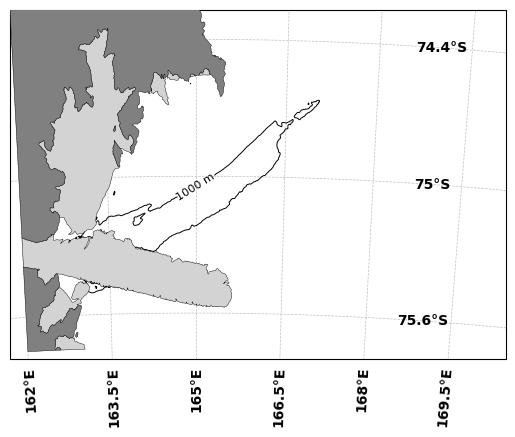

In [10]:
# starting from scratch... this is so fucking annoying 

# step 1: set lat/lon extent 
# --- Define your region ---
lon_min, lon_max = 150, 180
lat_min, lat_max = -80, -70

# step 2: 
proj = ccrs.SouthPolarStereo(central_longitude=165)

fig, ax = plt.subplots(subplot_kw={"projection": proj})

ax.set_extent([162, 170, -75.75, -74.25], crs=ccrs.PlateCarree())

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.5,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'weight': 'bold'}
gl.ylabel_style = {'size': 10, 'weight': 'bold'}

# set latitude tick marks 
gl.ylocator = plt.FixedLocator([-75.6,-75, -74.4])
depth = -bath.sel(lat=slice(lat_min,lat_max),lon=slice(lon_min,lon_max))['elevation']

levels = [1000]

contours = ax.contour(
    depth['lon'],
    depth['lat'],
    depth,
    levels=levels,
    colors='black',
    linewidths=0.7,
    transform=ccrs.PlateCarree(),
    zorder=2
)
ax.clabel(contours, fmt='%d m', fontsize=8, inline=True, inline_spacing=1)

ax.add_geometries(
    ice_clip.geometry,
    crs=ccrs.PlateCarree(),
    facecolor='lightgrey',
    edgecolor='k',
    linewidth=0.3,
    zorder=3
)

ax.add_geometries(
    land_clip.geometry,
    crs=ccrs.PlateCarree(),
    facecolor='grey',
    edgecolor='k',
    linewidth=0.3,
    zorder=3
)


In [11]:
# make into a function 
def TNB_study_site():
    """
    """
    # step 2: 
    proj = ccrs.SouthPolarStereo(central_longitude=165)

    fig, ax = plt.subplots(subplot_kw={"projection": proj})

    ax.set_extent([162, 170, -75.75, -74.25], crs=ccrs.PlateCarree())

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color='gray',
        alpha=0.5,
        linestyle='--'
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10, 'weight': 'bold'}
    gl.ylabel_style = {'size': 10, 'weight': 'bold'}
    # set latitude tick marks 
    gl.ylocator = plt.FixedLocator([-75.6,-75, -74.4])

    depth = -bath.sel(lat=slice(lat_min,lat_max),lon=slice(lon_min,lon_max))['elevation']

    levels = [1000]

    contours = ax.contour(
        depth['lon'],
        depth['lat'],
        depth,
        levels=levels,
        colors='black',
        linewidths=0.7,
        transform=ccrs.PlateCarree(),
        zorder=2
    )
    ax.clabel(contours, fmt='%d m', fontsize=8, inline=True, inline_spacing=1)

    ax.add_geometries(
        ice_clip.geometry,
        crs=ccrs.PlateCarree(),
        facecolor='lightgrey',
        edgecolor='k',
        linewidth=0.3,
        zorder=3
    )

    ax.add_geometries(
        land_clip.geometry,
        crs=ccrs.PlateCarree(),
        facecolor='grey',
        edgecolor='k',
        linewidth=0.3,
        zorder=3
    )
    return fig, ax


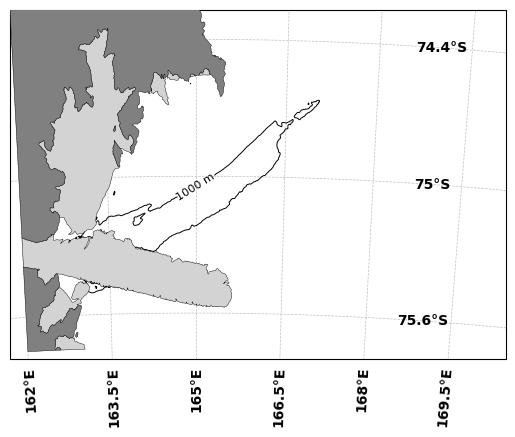

In [12]:
fig, ax = TNB_study_site()

In [13]:
import xarray as xr 
import matplotlib.pyplot as plt 
import numpy as np 
from scipy.signal import welch, csd
import pandas as pd


### Rotary Power Spectra 

**Goal:** Apply correlation and spectral relations to a vector timeseries (i.e. ocean currents) that is influenced by Earth's rotation. Earth's rotation can cause an asymmetry in fourier coefficients and we seek statistical relations that are invariant to rotation. 

A given velocity can be decomposed into a real and imaginary part, 

$$ u = u + iv $$

where $ i = \sqrt{-1} $

In Gonella (1972), four quantities are deemed useful: 

1. The mean kinetic energy (i.e. the total spectrum)

2. The rotary coefficient 

3. The orientation of the ellipse 

4. The stability of the ellipse 

Expanding on these, 

The mean kinetic energy, or the total spectrum, is defined as the summation of the clockwise ($ S_{-} $) and counterclockwise ($ S_{+} $) spectrums, 

$$ S_{t} = S_{-} + S_{+} $$

The rotary coefficient is defined as, 

$$ C_{R} = (S_{-} - S_{+}) / (S_{-} + S_{+}) $$



In [58]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import welch, csd

# def rotary_spectrum(u, v, fs, nperseg=256, **kwargs):
#     """
#     Compute the rotary power spectrum of 2D current data.

#     Parameters
#     ----------
#     u : array-like  — eastward velocity
#     v : array-like  — northward velocity
#     fs : float      — sampling frequency (Hz)
#     nperseg : int   — samples per Welch segment

#     Returns
#     -------
#     freq : ndarray  — frequencies (Hz), positive only
#     S_ccw : ndarray — CCW (counter-clockwise) spectrum
#     S_cw  : ndarray — CW  (clockwise) spectrum
#     """
#     # Auto- and cross-spectra using Welch's method
#     freq, Suu = welch(u, fs=fs, nperseg=nperseg, **kwargs)
#     _,    Svv = welch(v, fs=fs, nperseg=nperseg, **kwargs)
#     _,    Cuv = csd (u, v, fs=fs, nperseg=nperseg, **kwargs)  # complex cross-spectrum

#     # Rotary components
#     # S_ccw = (Suu + Svv + 2*Im(Cuv)) / 4   (CCW / positive freq)
#     # S_cw  = (Suu + Svv - 2*Im(Cuv)) / 4   (CW  / negative freq)
#     S_ccw = (Suu + Svv + 2 * np.imag(Cuv)) / 4
#     S_cw  = (Suu + Svv - 2 * np.imag(Cuv)) / 4

#     return freq, S_ccw, S_cw


# def rotary_coefficient(S_ccw, S_cw):
#     """
#     Rotary coefficient: +1 = pure CCW, -1 = pure CW, 0 = linear.
#     """
#     return (S_ccw - S_cw) / (S_ccw + S_cw)


# # --- Example usage ---
# fs = 1 / 3600          # 1-hour sampling → fs in Hz
# N  = 4096
# t  = np.arange(N) / fs

# # Synthetic inertial oscillation (CW in Northern Hemisphere)
# f_inertial = 1 / (18 * 3600)   # ~18-hour period
# u =  np.cos(2 * np.pi * f_inertial * t) + 0.1 * np.random.randn(N)
# v = -np.sin(2 * np.pi * f_inertial * t) + 0.1 * np.random.randn(N)

# freq, S_ccw, S_cw = rotary_spectrum(u, v, fs=fs, nperseg=512,
#                                     window='hann', detrend='linear')

# # Convert freq to cycles per day for oceanographic convention
# cpd = freq * 86400

# # --- Plot ---
# fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# ax = axes[0]
# ax.semilogy(cpd, S_ccw, label='CCW (+)', color='steelblue')
# ax.semilogy(cpd, S_cw,  label='CW  (−)', color='tomato', linestyle='--')
# ax.axvline(f_inertial * 86400, color='gray', linestyle=':', label='f_inertial')
# ax.set_ylabel('Power spectral density [(m/s)²/cpd]')
# ax.set_title('Rotary Power Spectrum')
# ax.legend()
# ax.grid(True, which='both', alpha=0.3)

# rc = rotary_coefficient(S_ccw, S_cw)
# axes[1].plot(cpd, rc, color='purple')
# axes[1].axhline(0, color='k', linewidth=0.8)
# axes[1].set_xlabel('Frequency [cpd]')
# axes[1].set_ylabel('Rotary coefficient')
# axes[1].set_title('Rotary Coefficient (−1 = CW, +1 = CCW)')
# axes[1].set_ylim(-1.1, 1.1)
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

In [59]:
# load in TNBD current meter data from bottom sensor (~1130 meters)
vel = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/tnbd_2018_vel_bot_1093.nc')

In [60]:
vel

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 28610)
Coordinates:
  * time     (time) datetime64[ns] 229kB 2018-03-12 ... 2019-01-03T23:59:54
    lat      float64 8B ...
    lon      float64 8B ...
    z        int64 8B ...
Data variables:
    u        (time) float64 229kB ...
    v        (time) float64 229kB ...
    w        (time) float64 229kB ...
    pres     (time) float64 229kB ...
    speed    (time) float64 229kB ...
    dir      (time) float64 229kB ...

In [61]:
# step 1: define u, v, fs, and nperseg (to be used in power spectra calculation)
u = vel.u
v= vel.v
fs = 1/900 # 15 minutes
nperseg = 5722

# other nperseg values to try: 
# 5722 --> 5 segments 
# 4096 --> 13 segments 
# 2048 --> 27 segments 
# 1024 --> 55 segments 

In [62]:
# step2: compute auto spectra 
# computing spectra using welch function from scipy 
# This function segments the data into a certain amount and takes the average spectra 

freq, Suu = welch(u,fs=fs, nperseg=nperseg)
_, Svv = welch(v,fs=fs, nperseg=nperseg)

In [63]:
Svv

array([3.27189662e+06, 1.18995350e+07, 1.07293936e+07, ...,
       2.18020081e+03, 1.49034273e+03, 6.89296608e+02], shape=(2862,))

In [64]:
# step 3: compute cross spectra 
_, Cuv = csd(u,v,fs=fs, nperseg=nperseg)

In [65]:
Suu

array([1.09195171e+06, 7.55109401e+06, 5.18492487e+06, ...,
       1.63002362e+03, 1.24783569e+03, 4.97358073e+02], shape=(2862,))

In [66]:
# step 4: split into clockwise and anticlockwise rotary components 
S_ccw = (Suu + Svv + 2*np.imag(Cuv))/4

S_cw = (Suu + Svv - 2*np.imag(Cuv))/4

In [67]:
%matplotlib widget

Text(0.5, 0, 'Period (hours)')

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_52034/1998609681.py:16: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


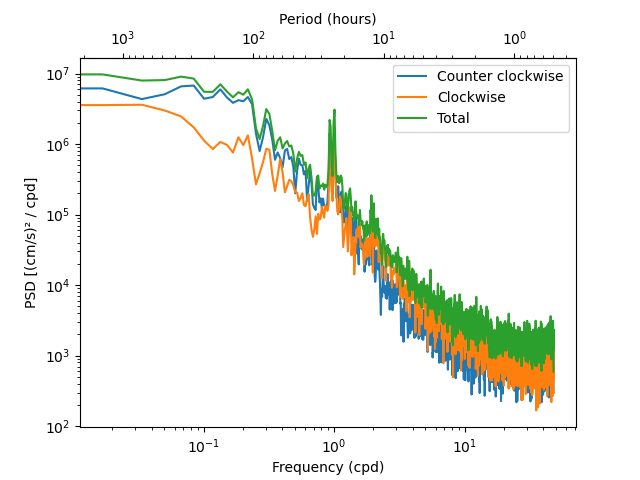

In [68]:
fig = plt.figure()
plt.loglog(freq * 86400, S_ccw, label='Counter clockwise')
plt.loglog(freq * 86400, S_cw,  label='Clockwise')
plt.loglog(freq * 86400, (S_ccw + S_cw), label='Total')
plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

# Grab the current axis to add the secondary axis
ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f

def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')


### CTD data 

In [69]:
# # Load data - DELL 
# df = pd.read_csv("/Users/mblan/Documents/research/data/ctd.csv")

# load data - MAC 
df = pd.read_csv('/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/ctd_012018_palmer.csv')

# Use station as the only dimension
ds = df.set_index('Station').to_xarray()

In [70]:
# 1. Rename the current dimension to reflect observation number 
ds1 = ds.rename_dims({'Station': 'obs'}).rename_vars({'Station': 'station'})

# 2. Build a sample index within each station
station_vals = ds1['station'].values

sample = np.zeros(len(station_vals), dtype=int)
count = {}

for i, st in enumerate(station_vals):
    sample[i] = count.get(st, 0)
    count[st] = count.get(st, 0) + 1

# 3. Attach sample as a coordinate on obs
ds1 = ds1.assign_coords(sample=('obs', sample))

# 4. Reshape from long -> 2D
ds2 = ds1.set_index(obs=['station', 'sample']).unstack('obs')

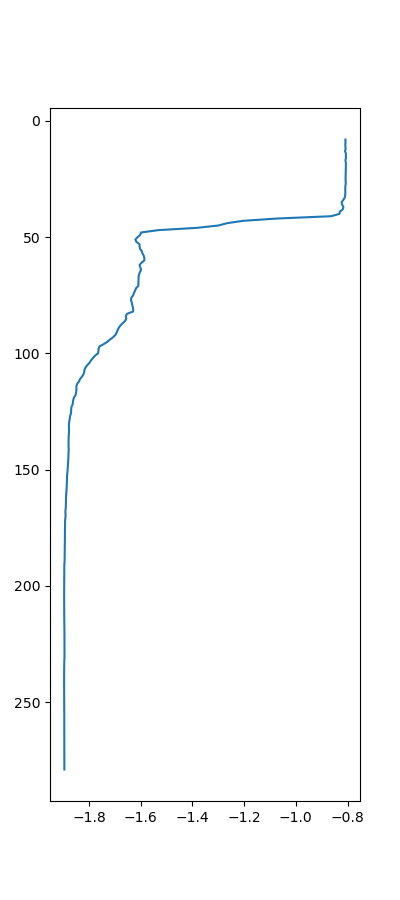

In [72]:
# plot a cast 
# define station to easily sub in 
station_sel = 70
fig = plt.figure(figsize=(4,9))
plt.plot(ds2.sel(station=station_sel).Temperature,ds2.sel(station=station_sel).Pressure)
plt.gca().invert_yaxis()

In [73]:
# reformat lat / lon to be coordinates 
lat1d = ds2['Latitude'].isel(sample=0)
lon1d = ds2['Longitude'].isel(sample=0)

ds2 = ds2.assign_coords(
    lat=('station', lat1d.values),
    lon=('station', lon1d.values)
)

In [74]:
ds2 = ds2.drop_vars(['Latitude', 'Longitude'])

In [76]:
# select Drygalski Trough region 
ds_sub = ds2.where(
    (ds2.lon > 163) & (ds2.lon < 167) &
    (ds2.lat > -76) & (ds2.lat < -74),
    drop=True
)

In [77]:
ds_sub

<xarray.Dataset> Size: 11MB
Dimensions:                  (station: 41, sample: 1522)
Coordinates:
  * station                  (station) int64 328B 22 23 24 25 26 ... 77 78 79 80
  * sample                   (sample) int64 12kB 0 1 2 3 ... 1518 1519 1520 1521
    lat                      (station) float64 328B -75.0 -75.0 ... -74.86
    lon                      (station) float64 328B 165.4 165.8 ... 164.8 164.9
Data variables: (12/23)
    Date                     (station, sample) object 499kB '2018-01-09' ... nan
    Julian_Day               (station, sample) float64 499kB 9.197 9.197 ... nan
    ISO_DateTime_UTC         (station, sample) object 499kB '2018-01-09T04:43...
    Pressure                 (station, sample) float64 499kB 1.0 2.0 ... nan nan
    Depth                    (station, sample) float64 499kB 0.982 1.978 ... nan
    Temperature              (station, sample) float64 499kB 0.7381 ... nan
    ...                       ...
    Scan_Count               (station, sample) float64 499kB 7.5e+03 ... nan
    Salinity                 (station, sample) float64 499kB 34.56 34.56 ... nan
    Salinity_2               (station, sample) float64 499kB 34.57 34.57 ... nan
    Oxygen_Saturation        (station, sample) float64 499kB 7.883 7.883 ... nan
    Scans_bin                (station, sample) float64 499kB 25.0 53.0 ... nan
    Flag                     (station, sample) float64 499kB 0.0 0.0 ... nan nan

Text(0.5, 1.0, 'Map 3: CTD Casts in TNB Drygalski Trough')

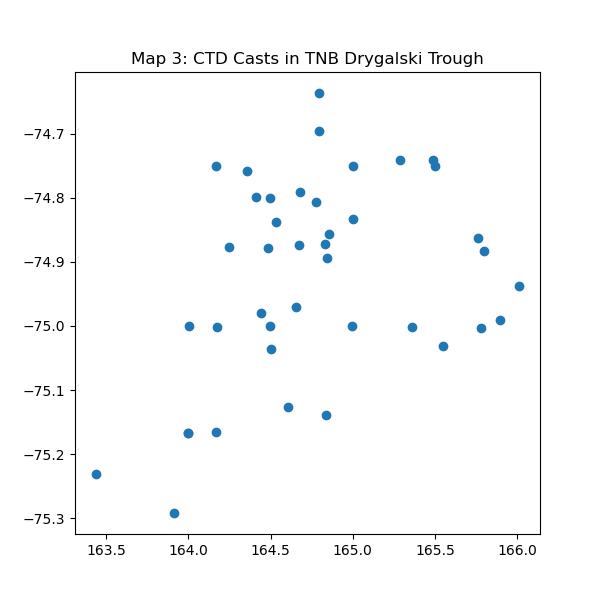

In [78]:
fig = plt.figure(figsize=(6,6))
plt.scatter(ds_sub.lon,ds_sub.lat)
plt.title('Map 3: CTD Casts in TNB Drygalski Trough')

In [79]:
ds_sub['Absolute_Salinity'] = gsw.SA_from_SP(ds_sub.Salinity,ds_sub.Pressure,ds_sub.lon,ds_sub.lat)
# should a reference pressure of zero be used? 
ds_sub['Potential_Temperature'] = gsw.pt_from_t(ds_sub.Absolute_Salinity,ds_sub.Temperature,ds_sub.Pressure,0)
ds_sub['Conservative_Temperature'] = gsw.CT_from_pt(ds_sub.Absolute_Salinity,ds_sub.Potential_Temperature)
ds_sub['Potential_Density'] = gsw.sigma0(ds_sub.Absolute_Salinity,ds_sub.Conservative_Temperature)

In [80]:
%matplotlib widget 

In [81]:
plt.close('all')

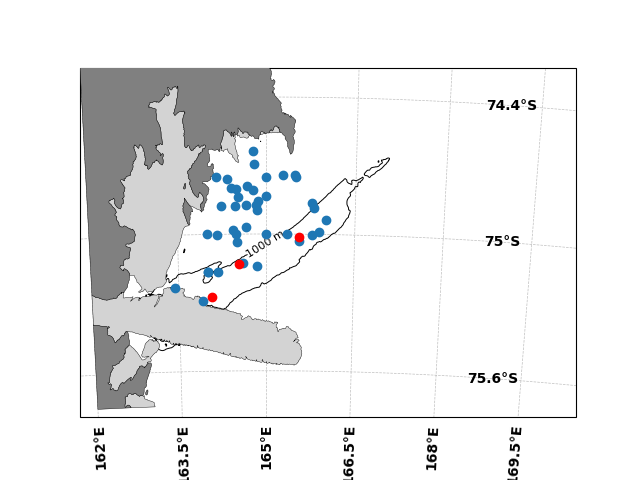

In [82]:
fig, ax = TNB_study_site()

ax.scatter(
    ds_sub.lon,
    ds_sub.lat,
    transform=ccrs.PlateCarree(),
    zorder=10
)

ax.scatter(ditd_lon,ditd_lat,transform=ccrs.PlateCarree(),
    zorder=10,color='r')
ax.scatter(tnbd_lon,tnbd_lat,transform=ccrs.PlateCarree(),
    zorder=10,color='r')
ax.scatter(D_lon,D_lat,transform=ccrs.PlateCarree(),
    zorder=10,color='r')

# # add station labels
# for i in range(len(ds_sub.station)):
#     ax.text(
#         ds_sub.lon.isel(station=i).item(),
#         ds_sub.lat.isel(station=i).item(),
#         str(ds_sub.station.isel(station=i).item()),
#         transform=ccrs.PlateCarree(),
#         fontsize=8,
#         ha='center',
#         va='bottom',   # puts label above point
#         zorder=11
#     )

Text(0.5, 0.98, 'Station 76, 2018-02-17')

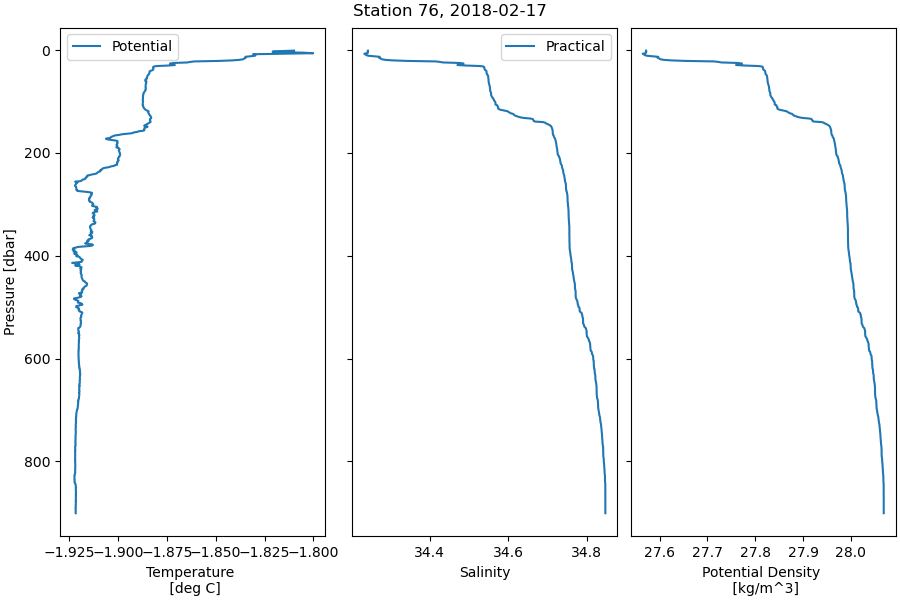

In [83]:
station = 76
ds_st = ds_sub.sel(station=station)

fig, axes = plt.subplots(1, 3, figsize=(9,6), constrained_layout=True, sharey=True)

# 1st panel
axes[0].plot(ds_st.Potential_Temperature, ds_st.Pressure,label='Potential')
# axes[0].plot(ds_st.Temperature, ds_st.Pressure,label='In-Situ')
# axes[0].plot(ds_st.Conservative_Temperature, ds_st.Pressure,label='Conservative')
axes[0].legend()
axes[0].set_xlabel('Temperature \n [deg C]')
axes[0].set_ylabel('Pressure [dbar]')
axes[0].invert_yaxis()

# 2nd panel
# axes[1].plot(ds_st.Absolute_Salinity, ds_st.Pressure,label='Absolute')
axes[1].plot(ds_st.Salinity, ds_st.Pressure,label='Practical')
axes[1].legend()
axes[1].set_xlabel('Salinity')
axes[1].invert_yaxis()

# 3rd panel
axes[2].plot(ds_st.Potential_Density, ds_st.Pressure)
axes[2].set_xlabel('Potential Density \n [kg/m^3]')
axes[2].invert_yaxis()

# Title
st_num = ds_st.station.item()
date = ds_sub.Date.sel(station=station).isel(sample=0).item()

fig.suptitle(f'Station {st_num}, {date}')

In [84]:
casts = {}

for st in ds_sub.station.values:
    cast = ds_sub.sel(station=st).sortby('Pressure')

    mask = (
        np.isfinite(cast.Pressure) &
        np.isfinite(cast.Absolute_Salinity) &
        np.isfinite(cast.Conservative_Temperature)
    )
    cast = cast.isel(sample=mask)

    # remove duplicate pressures
    _, ind = np.unique(cast.Pressure.values, return_index=True)
    cast = cast.isel(sample=np.sort(ind))

    # build a new dataset with pressure as dimension
    cast_clean = xr.Dataset(
        data_vars=dict(
            Temperature=('pressure', cast.Temperature.values),
            Conservative_Temperature=('pressure', cast.Conservative_Temperature.values),
            Salinity=('pressure', cast.Salinity.values),
            Absolute_Salinity=('pressure', cast.Absolute_Salinity.values),
            Potential_Density=('pressure', cast.Potential_Density.values),
            Potential_Temperature=('pressure',cast.Potential_Temperature.values),
            depth=('pressure', cast.Depth.values) if 'Depth' in cast else ('pressure', np.full(len(cast.Pressure), np.nan)),
        ),
        coords=dict(
            pressure=('pressure', cast.Pressure.values),
            station=st,
            lat=float(cast.lat) if 'lat' in cast else np.nan,
            lon=float(cast.lon) if 'lon' in cast else np.nan,
            date=cast.isel(sample=0).ISO_DateTime_UTC.values,
        ),
        attrs=dict(
            date=str(cast.Date.isel(sample=0).values) if 'Date' in cast else ''
        )
    )

    casts[st] = cast_clean

In [85]:
# Calculate N2 and Rd, save as dictionaries keyed by station number 
N2_casts = {}
Rd_casts = {}

for st, cast in casts.items():
    SA = cast.Absolute_Salinity.values
    CT = cast.Conservative_Temperature.values
    p = cast.pressure.values
    lat = float(cast.lat)
    lon = float(cast.lon)

    N2, p_mid = gsw.Nsquared(SA, CT, p, lat=lat)

    N2_da = xr.DataArray(
        N2,
        dims=['p_mid'],
        coords={
            'p_mid': p_mid,
            'station': st,
            'lat': lat,
            'lon': lon,
        },
        name='N2',
        attrs={
            'long_name': 'Brunt-Vaisala frequency squared',
            'units': 's^-2'
        }
    )

    if 'Date' in cast:
        date_val = cast.Date.isel(sample=0).item() if 'sample' in cast.Date.dims else cast.Date.item()
        N2_da = N2_da.assign_coords(date=date_val)

    N2_casts[st] = N2_da

    N = np.where(N2 > 0, np.sqrt(N2), np.nan)
    H = float(cast.depth.max())
    f = np.abs(gsw.f(lat))

    Rd = (np.nanmean(N) * H) / f
    Rd_casts[st] = Rd

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_52034/3821440659.py:36: RuntimeWarning: invalid value encountered in sqrt
  N = np.where(N2 > 0, np.sqrt(N2), np.nan)
/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_52034/3821440659.py:36: RuntimeWarning: invalid value encountered in sqrt
  N = np.where(N2 > 0, np.sqrt(N2), np.nan)
/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_52034/3821440659.py:36: RuntimeWarning: invalid value encountered in sqrt
  N = np.where(N2 > 0, np.sqrt(N2), np.nan)
/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_52034/3821440659.py:36: RuntimeWarning: invalid value encountered in sqrt
  N = np.where(N2 > 0, np.sqrt(N2), np.nan)
/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_52034/3821440659.py:36: RuntimeWarning: invalid value encountered in sqrt
  N = np.where(N2 > 0, np.sqrt(N2), np.nan)
/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_52034/3821440659.py:36: RuntimeWarning: invalid value en

In [86]:
N2_casts.keys()

dict_keys([np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78), np.int64(79), np.int64(80)])

In [87]:
cast = N2_casts[22]

In [88]:
cast = cast.coarsen(p_mid=5,boundary='trim').mean()

In [89]:
cast

<xarray.DataArray 'N2' (p_mid: 218)> Size: 2kB
array([ 3.17233351e-07,  1.84809024e-05,  1.22530556e-04,  1.18833462e-04,
        3.69296942e-05,  5.40740089e-05,  5.53691706e-05,  3.13645312e-05,
        1.25478835e-05,  1.13132749e-05,  7.25913969e-06,  6.41797185e-06,
        4.23020016e-06,  2.03136934e-06,  1.89964061e-06,  1.82337891e-06,
        3.05159658e-06,  1.25256875e-06,  2.60496324e-06,  1.10641537e-06,
        1.13564448e-06,  1.11402483e-06,  1.60451403e-06,  7.46634795e-07,
        1.66416998e-06,  7.30274649e-07,  1.10823633e-06,  8.38588192e-07,
        6.08864859e-07,  8.98445259e-07,  1.35627041e-06,  1.01131073e-06,
        1.15795769e-06,  8.21103541e-07,  2.30223253e-06,  1.85006976e-06,
        2.07558678e-06,  7.39764497e-07,  1.79887513e-06,  2.60498428e-06,
        2.31610119e-06,  1.71948009e-06,  2.39252674e-06,  1.08423945e-06,
        1.50513945e-06,  8.04573271e-07,  2.92553027e-06,  1.09445505e-06,
        2.33034679e-06,  5.66889642e-07,  7.42588932e-07,  1.49218477e-06,
        2.27774447e-07,  5.62127108e-07,  9.13853673e-07,  3.43376820e-07,
        4.93079038e-07,  1.58938273e-07,  6.85329615e-07, -4.58697018e-09,
        8.59436443e-07,  1.12251779e-07,  7.38075597e-07,  5.52447012e-07,
        6.68492767e-07,  6.65612906e-07,  9.54772771e-08,  2.51464999e-07,
        9.34158630e-07,  1.48859765e-06,  1.25519327e-06,  9.74529331e-07,
        7.28918375e-07,  1.70537356e-06,  4.46036260e-07,  3.98707947e-07,
        1.72361629e-07,  1.99485643e-07,  7.10510304e-07,  1.05066766e-06,
...
        1.53337267e-07,  1.11189071e-06,  9.57130178e-07,  1.12267522e-06,
        6.35831754e-07,  9.47528204e-07,  1.09361088e-06,  9.47575491e-07,
        7.91775483e-07,  7.81940921e-07,  6.36043710e-07,  6.36064506e-07,
        4.70379335e-07,  9.57655339e-07,  6.36191860e-07,  1.68978375e-07,
        6.36275933e-07,  9.27579728e-07,  4.80607140e-07,  1.10354915e-06,
        4.70535531e-07,  1.09932952e-06,  6.29451881e-07,  6.29472482e-07,
        1.56359392e-06,  9.51255482e-07,  4.63572831e-07, -3.14688612e-07,
        9.40963406e-07, -3.29336524e-09,  4.74139621e-07,  6.29832329e-07,
        3.08082871e-07,  3.08098784e-07,  6.29942381e-07,  1.63210667e-07,
        3.08201984e-07,  1.63346631e-07,  1.52691629e-07,  6.30175269e-07,
        1.52780839e-07,  3.08586681e-07,  1.42552691e-07,  1.53435528e-07,
        4.75431435e-07,  4.64547412e-07,  1.53543253e-07,  1.64603363e-07,
        1.42620862e-07, -1.79027421e-09,  3.09184978e-07,  1.64881278e-07,
        4.75870351e-07, -1.79399083e-07,  3.09325526e-07,  1.53953779e-07,
        3.09406688e-07,  6.20264623e-07, -1.32405324e-09,  3.20874903e-07,
        4.42172979e-07,  6.08939078e-07,  3.09627424e-07,  4.07630816e-07,
        1.31348818e-07,  2.21276171e-08,  1.08230156e-07,  1.54492751e-07,
       -1.67726065e-07,  1.66243168e-07, -6.64283439e-10,  3.21701032e-07,
       -1.55836642e-07,  1.31240506e-07, -1.55725253e-07,  3.21964000e-07,
        1.66777042e-07, -1.67398207e-07])
Coordinates:
  * p_mid    (p_mid) float64 2kB 3.5 8.5 13.5 ... 1.078e+03 1.084e+03 1.088e+03
    station  int64 8B 22
    lat      float64 8B -75.0
    lon      float64 8B 165.4
Attributes:
    long_name:  Brunt-Vaisala frequency squared
    units:      s^-2

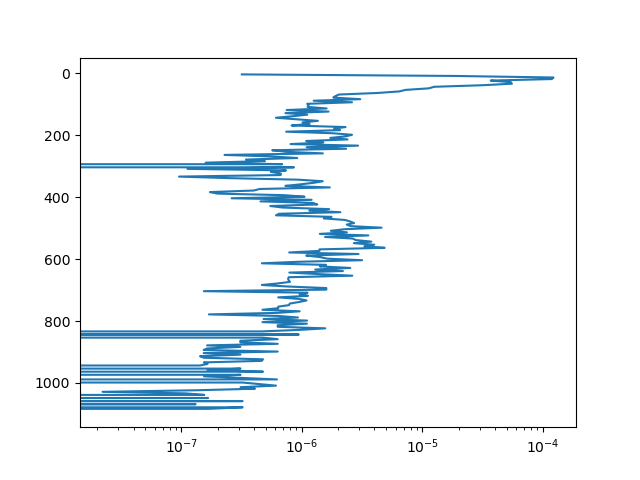

In [91]:
fig = plt.figure()
plt.semilogx(cast,cast.p_mid)
plt.gca().invert_yaxis()

In [126]:
# # Loop through casts and save plots of temp, sal, density, and N2 for each cast 
# # make output folder
# out_dir = 'ctd_plots'
# os.makedirs(out_dir, exist_ok=True)

# for st, cast in casts.items():

#     fig, axes = plt.subplots(1, 4, figsize=(11,6), constrained_layout=True, sharey=True)

#     # 1st panel
#     axes[0].plot(cast.Potential_Temperature, cast.pressure,color='k')
#     axes[0].set_xlabel('Potential Temperature \n [deg C]')
#     axes[0].set_ylabel('Pressure [dbar]')
#     axes[0].invert_yaxis()

#     # 2nd panel
#     axes[1].plot(cast.Absolute_Salinity, cast.pressure,color='k')
#     axes[1].set_xlabel('Absolute Salinity \n [g/kg]')
#     axes[1].invert_yaxis()

#     # 3rd panel
#     axes[2].plot(cast.Potential_Density, cast.pressure,color='k')
#     axes[2].set_xlabel('Potential Density \n [kg/m$^3$]')
#     axes[2].invert_yaxis()

#     # 4th panel 
#     axes[3].plot(N2_casts[st],N2_casts[st].p_mid,color='k')
#     axes[3].set_xlabel(r'N$^2$ [s$^{-1}$]')
#     axes[3].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
#     axes[3].xaxis.get_offset_text().set_size(10)

#     # Title
#     st_num = cast.station.item()
#     date = cast.date.item()

#     fig.suptitle(f'Station {st_num}, {date}')

#         # --- save figure ---
#     filename = f'station_{st}.png'
#     filepath = os.path.join(out_dir, filename)

#     plt.savefig(filepath, dpi=300)
#     plt.close(fig) 


The goal is to be able to estimate geostrophic velocity from dynamic height using two CTD casts. Each CTD cast has its own pressure coorindate and this will vary between casts. On a case by case basis, it makes sense to evaluate the pressure coordinate between casts to assess what the reference pressure should be for dynamic height calculation and what pressure grid to interpolate onto 

In [31]:
# define casts 
cast1 = casts[24]
cast2 = casts[22]

In [92]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import numpy as np

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})


def plot_tw_geo_vel_summary(
    cast1,
    cast2,
    bath,
    ice_clip,
    land_clip,
    Rd_casts,
    ditd_lon, ditd_lat,
    tnbd_lon, tnbd_lat,
    D_lon, D_lat,
    lat_min, lat_max,
    lon_min, lon_max,
    int_from_top=False,
    save_path=None,
    dpi=150,
):
    """
    Five-panel summary figure for thermal wind geostrophic velocity analysis.

    Layout
    ------
    [ empty ]  [ MAP (top center) ]  [ empty ]
    [ CTD raw ] [ CTD interp ]  [ density grad ] [ geo vel ]
      (bottom row: 2x2 grid)

    Parameters
    ----------
    cast1, cast2    : xarray Datasets with CTD data
    bath            : xarray Dataset with 'elevation' variable on lat/lon
    ice_clip        : GeoDataFrame for ice shelf geometry
    land_clip       : GeoDataFrame for land geometry
    Rd_casts        : dict  {station_number: Rd_value_in_meters}
    ditd_lon/lat    : float  — DITD mooring location
    tnbd_lon/lat    : float  — TNBD mooring location
    D_lon/D_lat     : float  — D mooring location
    lat_min/max     : float  — bounding box for bathymetry extraction
    lon_min/max     : float  — bounding box for bathymetry extraction
    int_from_top    : bool   — integration direction for tw_geo_vel
    save_path       : str or None  — if given, saves figure to this path
    dpi             : int    — resolution for saved figure

    Returns
    -------
    fig : matplotlib Figure
    axes : dict with keys 'map', 'ctd_raw', 'ctd_interp', 'drho', 'vel'
    """

    # ------------------------------------------------------------------ #
    #  Run geostrophic velocity calculation                                #
    # ------------------------------------------------------------------ #
    (cast1_depth, cast2_depth,
     cast1_depth_interp, cast2_depth_interp,
     dx, drho_dx, shear, v_tw) = tw_geo_vel(cast1, cast2, int_from_top=False)

    shear_sfc = tw_geo_vel(cast1, cast2, int_from_top=True)[6]
    v_tw_sfc  = tw_geo_vel(cast1, cast2, int_from_top=True)[7]

    # ------------------------------------------------------------------ #
    #  Build figure layout                                                 #
    # ------------------------------------------------------------------ #
    fig = plt.figure(figsize=(10, 13))  # close to letter page with margins

    outer = gridspec.GridSpec(
        2, 1,
        figure=fig,
        height_ratios=[1.0, 2.0],   # map compact, profiles get 2/3 of page
        hspace=0.4,
    )

    top_gs = gridspec.GridSpecFromSubplotSpec(
        1, 3,
        subplot_spec=outer[0],
        width_ratios=[0.2, 1, 0.2],
    )

    bot_gs = gridspec.GridSpecFromSubplotSpec(
        2, 2,
        subplot_spec=outer[1],
        hspace=0.5,
        wspace=0.4,
    )

    # ------------------------------------------------------------------ #
    #  Panel 1 — Map (top centre)                                         #
    # ------------------------------------------------------------------ #
    proj = ccrs.SouthPolarStereo(central_longitude=165)
    ax_map = fig.add_subplot(top_gs[0, 1], projection=proj)

    ax_map.set_extent([162, 170, -75.75, -74.25], crs=ccrs.PlateCarree())

    gl = ax_map.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color='gray',
        alpha=0.5,
        linestyle='--',
    )
    gl.top_labels    = False
    gl.right_labels  = False
    gl.xlabel_style  = {'size': 9, 'weight': 'bold'}
    gl.ylabel_style  = {'size': 9, 'weight': 'bold'}
    gl.ylocator      = plt.FixedLocator([-75.6, -75, -74.4])

    # Bathymetry contour
    depth = -bath.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))['elevation']
    contours = ax_map.contour(
        depth['lon'], depth['lat'], depth,
        levels=[400, 600, 800, 1000, 1100],
        colors='black', linewidths=0.7,
        transform=ccrs.PlateCarree(), zorder=2,
    )
    ax_map.clabel(contours, fmt='%d m', fontsize=7, inline=True, inline_spacing=1)

    # Ice & land
    ax_map.add_geometries(
        ice_clip.geometry, crs=ccrs.PlateCarree(),
        facecolor='lightgrey', edgecolor='k', linewidth=0.3, zorder=3,
    )
    ax_map.add_geometries(
        land_clip.geometry, crs=ccrs.PlateCarree(),
        facecolor='grey', edgecolor='k', linewidth=0.3, zorder=3,
    )

    # CTD cast locations
    for cast, color in [(cast1, 'tab:blue'), (cast2, 'tab:blue')]:
        ax_map.scatter(
            cast.lon, cast.lat,
            transform=ccrs.PlateCarree(), zorder=11, color=color, s=40,
        )
        ax_map.text(
            cast.lon.item(), cast.lat.item(),
            str(cast.station.item()),
            transform=ccrs.PlateCarree(),
            fontsize=8, ha='center', va='bottom', zorder=11,
        )

    # Mooring locations
    for mlon, mlat in [(ditd_lon, ditd_lat), (tnbd_lon, tnbd_lat), (D_lon, D_lat)]:
        ax_map.scatter(
            mlon, mlat,
            transform=ccrs.PlateCarree(), zorder=10, color='r', s=40,
        )

    # Title with cast metadata
    st1, st2    = cast1.station.item(), cast2.station.item()
    date1, date2 = cast1.date.item(), cast2.date.item()
    Rd1, Rd2    = Rd_casts[st1], Rd_casts[st2]
    ax_map.set_title(
        f'Cast {st1} ({date1})  Rd={Rd1/1000:.1f} km\n'
        f'Cast {st2} ({date2})  Rd={Rd2/1000:.1f} km   '
        f'dx={dx/1000:.1f} km',
        fontsize=10,
    )

    # ------------------------------------------------------------------ #
    #  Panel 2 — CTD raw profiles  (bottom left)                          #
    # ------------------------------------------------------------------ #
    ax_ctd = fig.add_subplot(bot_gs[0, 0])
    ax_ctd.plot(cast1_depth.Potential_Density, cast1_depth.depth,
                label=f'Stn {cast1_depth.station.values}')
    ax_ctd.plot(cast2_depth.Potential_Density, cast2_depth.depth,
                label=f'Stn {cast2_depth.station.values}')
    ax_ctd.invert_yaxis()
    ax_ctd.set_ylabel('Depth [m]')
    ax_ctd.set_xlabel('Pot. Density [kg m⁻³]')
    ax_ctd.set_title('CTD Profiles')
    ax_ctd.legend(fontsize=8)

    # ------------------------------------------------------------------ #
    #  Panel 3 — CTD interpolated profiles  (bottom right of top sub-row) #
    # ------------------------------------------------------------------ #
    ax_interp = fig.add_subplot(bot_gs[0, 1])
    ax_interp.plot(cast1_depth_interp.Potential_Density, cast1_depth_interp.depth,
                   label=f'Stn {cast1_depth_interp.station.values}')
    ax_interp.plot(cast2_depth_interp.Potential_Density, cast2_depth_interp.depth,
                   label=f'Stn {cast2_depth_interp.station.values}')
    ax_interp.invert_yaxis()
    ax_interp.set_ylabel('Depth [m]')
    ax_interp.set_xlabel('Pot. Density [kg m⁻³]')
    ax_interp.set_title('CTD Profiles (Interpolated)')
    ax_interp.legend(fontsize=8)

    # ------------------------------------------------------------------ #
    #  Panel 4 — Meridional density gradient  (bottom left of lower row)  #
    # ------------------------------------------------------------------ #
    ax_drho = fig.add_subplot(bot_gs[1, 0])
    ax_drho.plot(drho_dx, drho_dx.depth)
    ax_drho.axvline(0, color='k', linewidth=0.6, linestyle='--')
    ax_drho.invert_yaxis()
    ax_drho.set_ylabel('Depth [m]')
    ax_drho.set_xlabel('Density Gradient [kg m⁻³ m⁻¹]')
    ax_drho.set_title('Density Gradient')

    # ------------------------------------------------------------------ #
    #  Panel 5 — Geostrophic velocity  (bottom right of lower row)        #
    # ------------------------------------------------------------------ #
    ax_vel = fig.add_subplot(bot_gs[1, 1])
    ax_vel.plot(v_tw,     shear.dropna(dim='depth').depth,     label='upward')
    ax_vel.plot(v_tw_sfc, shear_sfc.dropna(dim='depth').depth, label='downward')
    ax_vel.axvline(0, color='k', linewidth=0.6, linestyle='--')
    ax_vel.invert_yaxis()
    ax_vel.set_ylabel('Depth [m]')
    ax_vel.set_xlabel('Geostrophic Velocity [m s⁻¹]')
    ax_vel.set_title('Baroclinic Velocity')
    ax_vel.legend(fontsize=8)

    # ------------------------------------------------------------------ #
    #  Save                                                                #
    # ------------------------------------------------------------------ #
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Figure saved → {save_path}')

    axes = {
        'map':       ax_map,
        'ctd_raw':   ax_ctd,
        'ctd_interp': ax_interp,
        'drho':      ax_drho,
        'vel':       ax_vel,
    }
    return fig, axes


# ------------------------------------------------------------------ #
#  Example call                                                        #
# ------------------------------------------------------------------ #
# fig, axes = plot_tw_geo_vel_summary(
#     cast1, cast2,
#     bath, ice_clip, land_clip,
#     Rd_casts,
#     ditd_lon, ditd_lat,
#     tnbd_lon, tnbd_lat,
#     D_lon, D_lat,
#     lat_min, lat_max,
#     lon_min, lon_max,
#     int_from_top=False,
#     save_path='tw_geo_vel_summary.png',   # or .pdf / .svg
# )
# plt.show()

In [98]:
cast1 = casts[23]
cast2 = casts[41]

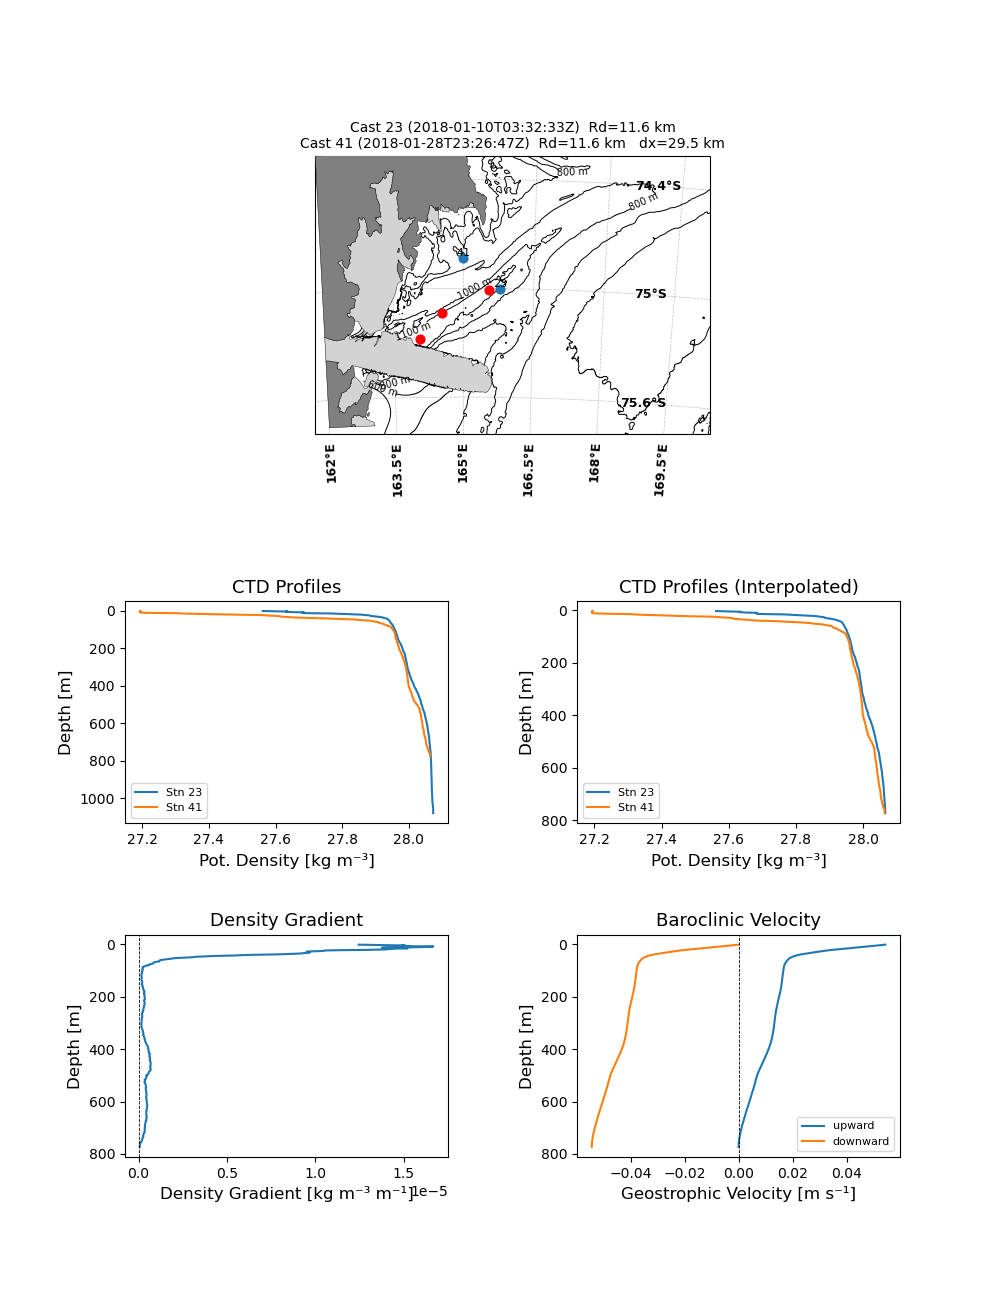

In [97]:
fig, axes = plot_tw_geo_vel_summary(
    cast1, cast2,
    bath, ice_clip, land_clip,
    Rd_casts,
    ditd_lon, ditd_lat,
    tnbd_lon, tnbd_lat,
    D_lon, D_lat,
    lat_min, lat_max,
    lon_min, lon_max,
    int_from_top=False,
    save_path=None,   # or .pdf / .svg
)
plt.show()

### Dynamic Height - piece wise 

In [ ]:

p1 = cast1.pressure[-1].values

In [285]:
p2 = cast2.pressure[-1].values

In [289]:
int(min(p1,p2))

882

In [290]:
# piece wise example that will be turned into a function 
# starting with casts 26 and 73
# in this example, cast 73 only goes down to 882 dbar, or 871 meters, this is the limting pressure 
# cast 26 extends down to 1159 dbar, or 1144 meters 
# So in this case, we will not be getting any information on what is going on below 871 meters!! 

# step 1: calculate dynamic height for a cast 
dyn1 = gsw.geo_strf_dyn_height(cast1.Absolute_Salinity, cast1.Conservative_Temperature, cast1.pressure, p_ref=int(min(p1,p2)))
dyn2 = gsw.geo_strf_dyn_height(cast2.Absolute_Salinity, cast2.Conservative_Temperature, cast2.pressure, p_ref=int(min(p1,p2)))



In [291]:
dyn1

array([0.53156508, 0.52542752, 0.51924603, ..., 0.06434092, 0.0646699 ,
       0.06499903], shape=(1151,))

In [292]:
dyn2

array([ 7.84112482e-01,  7.81547404e-01,  7.78984164e-01,  7.76422382e-01,
        7.73863372e-01,  7.71308325e-01,  7.68757508e-01,  7.66208802e-01,
        7.63657301e-01,  7.61104784e-01,  7.58554641e-01,  7.56005195e-01,
        7.53455880e-01,  7.50916204e-01,  7.48404188e-01,  7.45914542e-01,
        7.43429019e-01,  7.40938793e-01,  7.38429126e-01,  7.35900458e-01,
        7.33370074e-01,  7.30854764e-01,  7.28365280e-01,  7.25883154e-01,
        7.23399317e-01,  7.20937672e-01,  7.18513524e-01,  7.16133283e-01,
        7.13770742e-01,  7.11382761e-01,  7.08977197e-01,  7.06604656e-01,
        7.04257898e-01,  7.01900605e-01,  6.99556522e-01,  6.97242906e-01,
        6.94960483e-01,  6.92719464e-01,  6.90529478e-01,  6.88369838e-01,
        6.86223595e-01,  6.84093780e-01,  6.81972544e-01,  6.79855936e-01,
        6.77743884e-01,  6.75647341e-01,  6.73573817e-01,  6.71511877e-01,
        6.69450824e-01,  6.67394202e-01,  6.65343160e-01,  6.63295677e-01,
        6.61250574e-01,  

Text(0.5, 0, 'Dynamic Height [m]')

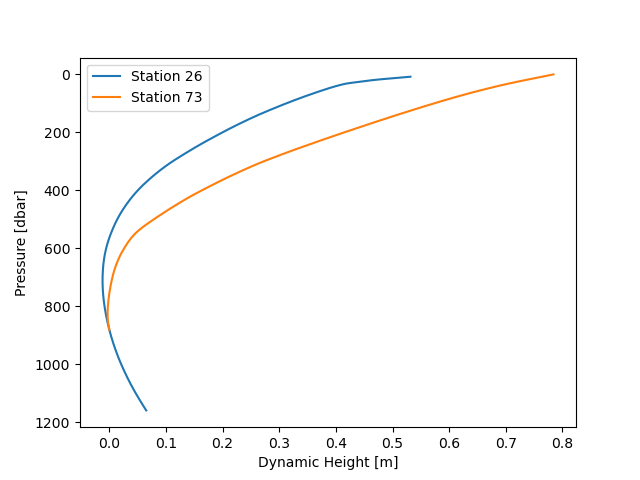

In [293]:
# plot them 
fig = plt.figure()
plt.plot(dyn1,cast1.pressure,label=f'Station {cast1.station.values}')
plt.plot(dyn2,cast2.pressure,label=f'Station {cast2.station.values}')
plt.gca().invert_yaxis()
plt.legend()
plt.ylabel('Pressure [dbar]')
plt.xlabel('Dynamic Height [m]')

In [296]:
# Question: For casts like above, should I interpolate station 26 to 800dbar using all data, or chop it off at 800 dbar then interpolate? 

# define common pressure grid - in this case, 0 to 800dbar 
p_grid = np.arange(0,(int(min(p1,p2))+1),1)

In [297]:
p_grid

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [298]:
cast1['dyn'] = ('pressure',dyn1)
cast2['dyn'] = ('pressure', dyn2)

In [299]:
cast1_interp = cast1.interp(pressure=p_grid,method='linear')
cast2_interp = cast2.interp(pressure=p_grid,method='linear')

In [301]:
# need to calculate distance between points 
# this give distance in meters 
dx = gsw.distance([cast1.lon, cast2.lon], [cast1.lat, cast2.lat])[0]

In [302]:
dx

np.float64(14921.853243998105)

In [303]:
# calculate coriolis 
f = gsw.f(0.5 * (cast1.lat + cast2.lat))

In [304]:
f

<xarray.DataArray 'lat' ()> Size: 8B
array(-0.00014093)

In [305]:
# estimate geostrophic velocity 
v_geo = (cast2_interp.dyn - cast1_interp.dyn)/(f*dx)

In [306]:
v_geo

<xarray.DataArray (pressure: 883)> Size: 7kB
array([            nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan, -1.10365185e-01, -1.12069956e-01, -1.13796741e-01,
       -1.15520956e-01, -1.17235278e-01, -1.18906592e-01, -1.20508710e-01,
       -1.22025896e-01, -1.23439066e-01, -1.24817876e-01, -1.26212720e-01,
       -1.27385751e-01, -1.28250038e-01, -1.29047733e-01, -1.29868352e-01,
       -1.30659239e-01, -1.31434765e-01, -1.32244567e-01, -1.33045123e-01,
       -1.33764696e-01, -1.34402451e-01, -1.35001031e-01, -1.35561329e-01,
       -1.36081458e-01, -1.36464705e-01, -1.36552720e-01, -1.36455621e-01,
       -1.36343868e-01, -1.36229018e-01, -1.36118556e-01, -1.36009439e-01,
       -1.35882138e-01, -1.35736396e-01, -1.35586686e-01, -1.35430464e-01,
       -1.35264782e-01, -1.35085147e-01, -1.34897098e-01, -1.34708252e-01,
       -1.34512381e-01, -1.34308227e-01, -1.34100192e-01, -1.33890143e-01,
       -1.33677314e-01, -1.33458084e-01, -1.33232724e-01, -1.33003255e-01,
       -1.32770192e-01, -1.32535028e-01, -1.32297571e-01, -1.32063651e-01,
       -1.31836532e-01, -1.31613389e-01, -1.31399545e-01, -1.31198219e-01,
       -1.31005041e-01, -1.30815701e-01, -1.30627286e-01, -1.30438435e-01,
       -1.30250641e-01, -1.30064495e-01, -1.29878182e-01, -1.29692745e-01,
       -1.29506631e-01, -1.29318814e-01, -1.29131009e-01, -1.28944048e-01,
       -1.28756648e-01, -1.28567441e-01, -1.28377406e-01, -1.28186041e-01,
...
       -2.61304505e-03, -2.56166614e-03, -2.51061295e-03, -2.45993258e-03,
       -2.40894088e-03, -2.35829821e-03, -2.30866486e-03, -2.25920043e-03,
       -2.21013202e-03, -2.16196375e-03, -2.11412053e-03, -2.06663784e-03,
       -2.01950378e-03, -1.97181913e-03, -1.92345148e-03, -1.87471310e-03,
       -1.82613163e-03, -1.77791063e-03, -1.72988215e-03, -1.68133879e-03,
       -1.63244851e-03, -1.58300773e-03, -1.53283662e-03, -1.48357731e-03,
       -1.43449866e-03, -1.38592444e-03, -1.33930493e-03, -1.29376494e-03,
       -1.24912463e-03, -1.20571960e-03, -1.16337002e-03, -1.12102108e-03,
       -1.07920012e-03, -1.03826665e-03, -9.97885074e-04, -9.58043382e-04,
       -9.18370023e-04, -8.79596013e-04, -8.43686566e-04, -8.10809298e-04,
       -7.78986844e-04, -7.48063477e-04, -7.18218896e-04, -6.88554400e-04,
       -6.58902297e-04, -6.29418188e-04, -6.00305943e-04, -5.71565547e-04,
       -5.44071390e-04, -5.18194953e-04, -4.92498497e-04, -4.66790179e-04,
       -4.41788799e-04, -4.17686145e-04, -3.94290344e-04, -3.71948592e-04,
       -3.50864815e-04, -3.30716060e-04, -3.12196700e-04, -2.95605201e-04,
       -2.79887769e-04, -2.64182531e-04, -2.48501697e-04, -2.32653428e-04,
       -2.15894715e-04, -1.99315695e-04, -1.83443111e-04, -1.67725752e-04,
       -1.52559572e-04, -1.37777149e-04, -1.22610976e-04, -1.07444815e-04,
       -9.24705443e-05, -7.74840186e-05, -6.21259852e-05, -4.64210027e-05,
       -3.08956399e-05, -1.53457143e-05, -0.00000000e+00])
Coordinates:
  * pressure  (pressure) int64 7kB 0 1 2 3 4 5 6 ... 876 877 878 879 880 881 882

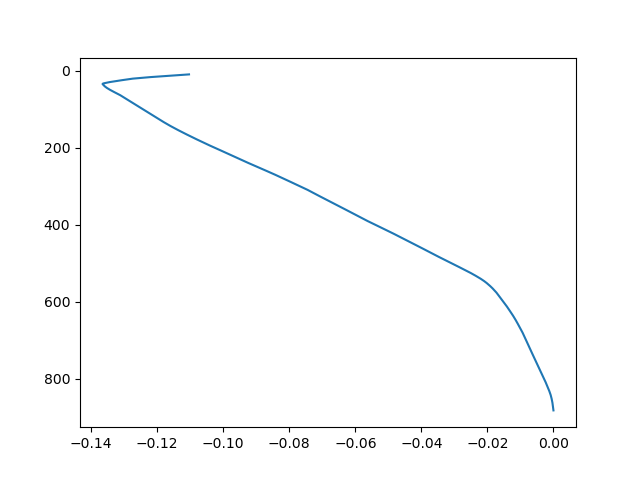

In [307]:
fig = plt.figure()
plt.plot(v_geo,v_geo.pressure)
plt.gca().invert_yaxis()

In [308]:
# cast1.to_netcdf('cast_26.nc')
# cast2.to_netcdf('cast_73.nc')

### Thermal Wind - piecewise 

In [47]:
cast1_depth_interp, cast2_depth_interp, drho_dx, v_tw, shear = tw_geo_vel(cast1=casts[24],cast2=casts[22])

In [48]:
len(shear.dropna('depth'))

1074

In [49]:
len(v_tw)

1074

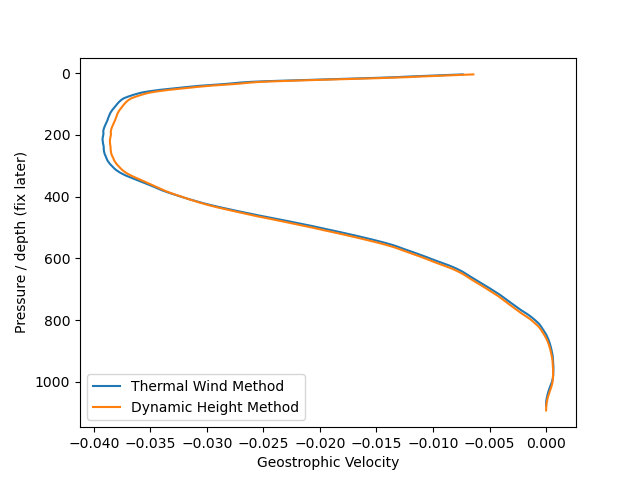

In [50]:
fig = plt.figure()
plt.plot(v_tw,shear.dropna(dim='depth').depth,label='Thermal Wind Method')
plt.plot(v_geo,v_geo.pressure, label='Dynamic Height Method')
plt.gca().invert_yaxis()
plt.ylabel('Pressure / depth (fix later)')
plt.xlabel('Geostrophic Velocity')
plt.legend()

### Thermal Wind -piecewise 

In [ ]:
## THERMAL WIND ESTIMATE 
# calculate drho_dx
g = 9.81
rho0 = 1028

drho_dx = (cast2_interp.Potential_Density - cast1_interp.Potential_Density)/dx

Text(0.5, 0, 'Zonal Density Gradient')

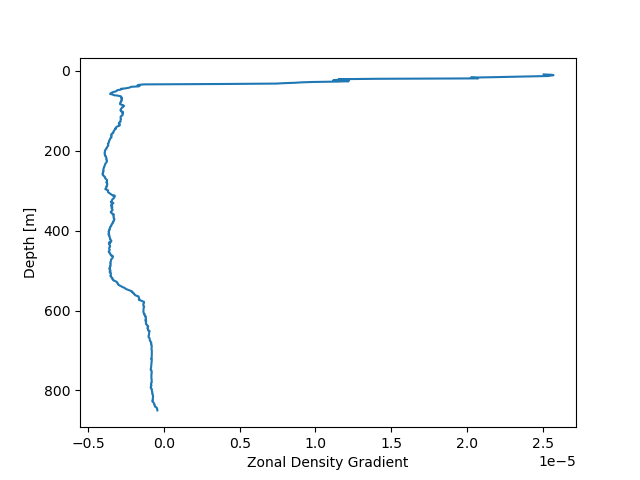

In [227]:
fig = plt.figure()
plt.plot(drho_dx,drho_dx.pressure)
plt.gca().invert_yaxis()
plt.ylabel('Depth [m]')
plt.xlabel('Zonal Density Gradient')

In [228]:
# estimate shear from thermal wind equation 
shear = -(g / (f * rho0)) * drho_dx

In [230]:
# vertically integrate 
v_tw = scipy.integrate.cumulative_trapezoid(shear.dropna(dim='pressure'),initial=0)

In [231]:
len(v_tw)

842

Text(0.5, 0, 'Geostrophic Velocity ')

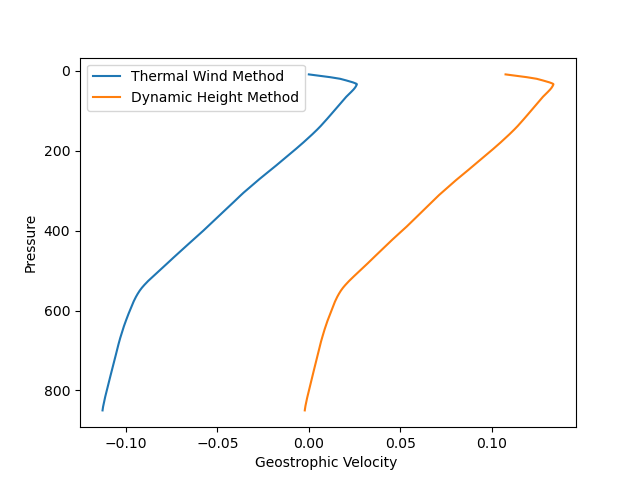

In [236]:
fig = plt.figure()
plt.plot(v_tw,shear.dropna(dim='pressure').pressure,label='Thermal Wind Method')
plt.plot(v_geo,v_geo.pressure, label='Dynamic Height Method')
plt.gca().invert_yaxis()
plt.legend()
plt.ylabel('Pressure')
plt.xlabel('Geostrophic Velocity ')

In [239]:
len(v_geo), len(v_tw)

(851, 842)

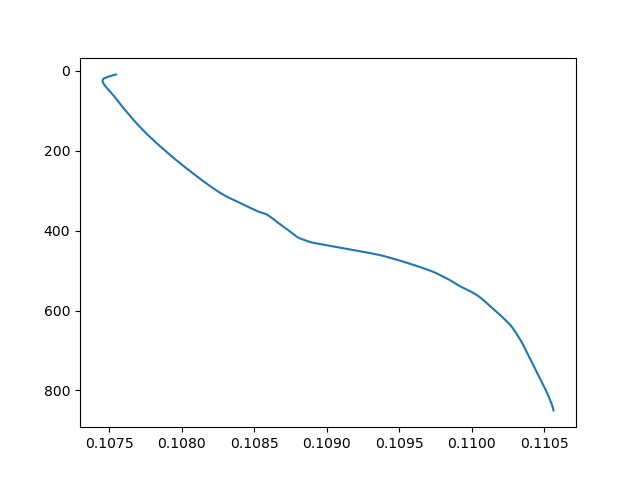

In [245]:
fig = plt.figure()
plt.plot((v_geo.dropna('pressure') - v_tw), v_geo.dropna('pressure').pressure)
plt.gca().invert_yaxis()

In [246]:
np.min(v_geo.dropna('pressure') - v_tw), np.max(v_geo.dropna('pressure') - v_tw)

(<xarray.DataArray ()> Size: 8B
 array(0.1074528),
 <xarray.DataArray ()> Size: 8B
 array(0.11056246))

In [247]:
cast1_depth = cast1.swap_dims({'pressure':'depth'})
cast2_depth = cast2.swap_dims({'pressure':'depth'})

In [248]:
# define common depth grid 
d_grid = np.arange(0,851,1)

In [249]:
cast1_depth_interp = cast1_depth.interp(depth=d_grid)
cast2_depth_interp = cast2_depth.interp(depth=d_grid)

In [250]:
# calculate drho_dx
g = 9.81
rho0 = 1028

drho_dx = (cast2_depth_interp.Potential_Density - cast1_depth_interp.Potential_Density)/dx

Text(0.5, 0, 'Zonal Density Gradient')

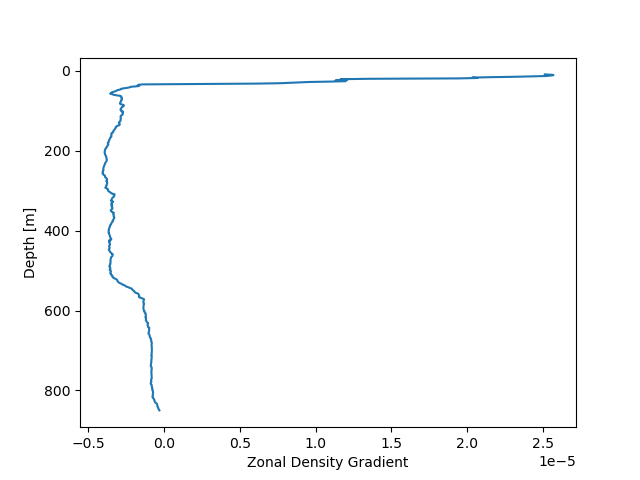

In [251]:
fig = plt.figure()
plt.plot(drho_dx,drho_dx.depth)
plt.gca().invert_yaxis()
plt.ylabel('Depth [m]')
plt.xlabel('Zonal Density Gradient')

In [252]:
drho_dx

<xarray.DataArray 'Potential_Density' (depth: 851)> Size: 7kB
array([            nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,  2.51105514e-05,  2.55940116e-05,  2.56820487e-05,
        2.54836708e-05,  2.52409463e-05,  2.40885429e-05,  2.30882528e-05,
        2.14480396e-05,  2.03307116e-05,  2.06749574e-05,  1.93992058e-05,
        1.35257951e-05,  1.16413252e-05,  1.20997916e-05,  1.19545391e-05,
        1.13194035e-05,  1.18606048e-05,  1.19896593e-05,  1.09802174e-05,
        9.55079258e-06,  8.89305861e-06,  8.37349213e-06,  7.73013899e-06,
        6.21635763e-06,  2.06290802e-06, -1.41728982e-06, -1.66774145e-06,
       -1.72987324e-06, -1.67488859e-06, -1.63499839e-06, -1.87196575e-06,
       -2.17958716e-06, -2.24307651e-06, -2.33462808e-06, -2.47827372e-06,
       -2.68058287e-06, -2.81469583e-06, -2.82413254e-06, -2.92857377e-06,
       -3.05197795e-06, -3.10857825e-06, -3.13974438e-06, -3.18147365e-06,
       -3.28306621e-06, -3.36759608e-06, -3.43257964e-06, -3.47967865e-06,
       -3.51384016e-06, -3.54540165e-06, -3.47523083e-06, -3.37900316e-06,
       -3.32406501e-06, -3.15638985e-06, -2.98373470e-06, -2.86712573e-06,
       -2.82613860e-06, -2.81061940e-06, -2.82733813e-06, -2.79217805e-06,
       -2.78405462e-06, -2.78128927e-06, -2.76625716e-06, -2.79053487e-06,
       -2.81005193e-06, -2.80288045e-06, -2.79058182e-06, -2.80710971e-06,
       -2.83482920e-06, -2.83553169e-06, -2.87116932e-06, -2.87723503e-06,
...
       -8.42134498e-07, -8.47472529e-07, -8.46443094e-07, -8.41058356e-07,
       -8.49367051e-07, -8.51715474e-07, -8.31889464e-07, -8.33660043e-07,
       -8.50392031e-07, -8.62943459e-07, -8.66236940e-07, -8.74301898e-07,
       -8.65141827e-07, -8.36181545e-07, -8.11536016e-07, -8.11306218e-07,
       -8.03428413e-07, -8.05901590e-07, -8.07213810e-07, -7.93238853e-07,
       -7.81613831e-07, -7.70099372e-07, -7.78621926e-07, -7.75175817e-07,
       -7.69845216e-07, -7.63929401e-07, -7.78826717e-07, -7.53872698e-07,
       -7.48150519e-07, -7.47656511e-07, -7.36557563e-07, -7.20543359e-07,
       -7.25561316e-07, -7.09836319e-07, -7.16210901e-07, -7.26864871e-07,
       -7.36809654e-07, -7.36530636e-07, -7.31016596e-07, -7.26207506e-07,
       -7.28496576e-07, -7.41306980e-07, -7.40747564e-07, -7.58740207e-07,
       -7.52950196e-07, -7.36308408e-07, -7.44291270e-07, -7.09997485e-07,
       -6.90812853e-07, -6.78235675e-07, -6.60197525e-07, -6.41696244e-07,
       -6.37721955e-07, -6.35873307e-07, -6.18024446e-07, -6.11898589e-07,
       -6.01603743e-07, -5.99514492e-07, -5.87230044e-07, -5.46558328e-07,
       -4.97321604e-07, -4.79786147e-07, -4.66580889e-07, -4.49769685e-07,
       -4.46896194e-07, -4.46721364e-07, -4.44210576e-07, -4.38119544e-07,
       -4.33152842e-07, -4.11235777e-07, -3.88727249e-07, -3.87444755e-07,
       -3.86343408e-07, -3.74035335e-07, -3.60945443e-07, -3.50031141e-07,
       -3.31813256e-07, -3.13303882e-07, -3.00316480e-07])
Coordinates:
  * depth    (depth) int64 7kB 0 1 2 3 4 5 6 7 ... 844 845 846 847 848 849 850

In [263]:
# estimate shear from thermal wind equation 
shear = (g / (f * rho0)) * drho_dx

In [264]:
shear

<xarray.DataArray (depth: 851)> Size: 7kB
array([            nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan, -1.70030337e-03, -1.73303977e-03, -1.73900100e-03,
       -1.72556829e-03, -1.70913276e-03, -1.63110041e-03, -1.56336806e-03,
       -1.45230479e-03, -1.37664748e-03, -1.39995730e-03, -1.31357271e-03,
       -9.15868179e-04, -7.88265624e-04, -8.19309625e-04, -8.09474188e-04,
       -7.66467438e-04, -8.03113637e-04, -8.11852272e-04, -7.43500229e-04,
       -6.46710006e-04, -6.02173059e-04, -5.66991807e-04, -5.23428625e-04,
       -4.20926393e-04, -1.39685083e-04,  9.59685282e-05,  1.12927285e-04,
        1.17134397e-04,  1.13411238e-04,  1.10710164e-04,  1.26755866e-04,
        1.47585743e-04,  1.51884779e-04,  1.58083984e-04,  1.67810619e-04,
        1.81509519e-04,  1.90590670e-04,  1.91229655e-04,  1.98301653e-04,
        2.06657684e-04,  2.10490243e-04,  2.12600587e-04,  2.15426188e-04,
        2.22305295e-04,  2.28029041e-04,  2.32429254e-04,  2.35618456e-04,
        2.37931624e-04,  2.40068738e-04,  2.35317282e-04,  2.28801446e-04,
        2.25081435e-04,  2.13727696e-04,  2.02036749e-04,  1.94140840e-04,
        1.91365491e-04,  1.90314644e-04,  1.91446714e-04,  1.89065930e-04,
        1.88515870e-04,  1.88328621e-04,  1.87310756e-04,  1.88954666e-04,
        1.90276219e-04,  1.89790618e-04,  1.88957845e-04,  1.90076993e-04,
        1.91953955e-04,  1.92001523e-04,  1.94414643e-04,  1.94825368e-04,
...
        5.70232053e-05,  5.73846577e-05,  5.73149519e-05,  5.69503367e-05,
        5.75129410e-05,  5.76719590e-05,  5.63294863e-05,  5.64493770e-05,
        5.75823451e-05,  5.84322363e-05,  5.86552468e-05,  5.92013470e-05,
        5.85810938e-05,  5.66201147e-05,  5.49512992e-05,  5.49357390e-05,
        5.44023115e-05,  5.45697770e-05,  5.46586310e-05,  5.37123488e-05,
        5.29251872e-05,  5.21455120e-05,  5.27225972e-05,  5.24892518e-05,
        5.21283024e-05,  5.17277266e-05,  5.27364641e-05,  5.10467600e-05,
        5.06592958e-05,  5.06258452e-05,  4.98743053e-05,  4.87899403e-05,
        4.91297197e-05,  4.80649376e-05,  4.84965778e-05,  4.92179869e-05,
        4.98913751e-05,  4.98724821e-05,  4.94991115e-05,  4.91734750e-05,
        4.93284741e-05,  5.01959012e-05,  5.01580216e-05,  5.13763522e-05,
        5.09842949e-05,  4.98574344e-05,  5.03979756e-05,  4.80758506e-05,
        4.67768073e-05,  4.59251725e-05,  4.47037606e-05,  4.34509888e-05,
        4.31818789e-05,  4.30567020e-05,  4.18481073e-05,  4.14333089e-05,
        4.07362171e-05,  4.05947482e-05,  3.97629350e-05,  3.70089431e-05,
        3.36749913e-05,  3.24876180e-05,  3.15934543e-05,  3.04551222e-05,
        3.02605504e-05,  3.02487122e-05,  3.00786999e-05,  2.96662597e-05,
        2.93299508e-05,  2.78458871e-05,  2.63217737e-05,  2.62349326e-05,
        2.61603574e-05,  2.53269445e-05,  2.44405925e-05,  2.37015555e-05,
        2.24679733e-05,  2.12146535e-05,  2.03352414e-05])
Coordinates:
  * depth    (depth) int64 7kB 0 1 2 3 4 5 6 7 ... 844 845 846 847 848 849 850

In [265]:
import scipy

In [266]:
shear.dropna(dim='depth')

<xarray.DataArray (depth: 842)> Size: 7kB
array([-1.70030337e-03, -1.73303977e-03, -1.73900100e-03, -1.72556829e-03,
       -1.70913276e-03, -1.63110041e-03, -1.56336806e-03, -1.45230479e-03,
       -1.37664748e-03, -1.39995730e-03, -1.31357271e-03, -9.15868179e-04,
       -7.88265624e-04, -8.19309625e-04, -8.09474188e-04, -7.66467438e-04,
       -8.03113637e-04, -8.11852272e-04, -7.43500229e-04, -6.46710006e-04,
       -6.02173059e-04, -5.66991807e-04, -5.23428625e-04, -4.20926393e-04,
       -1.39685083e-04,  9.59685282e-05,  1.12927285e-04,  1.17134397e-04,
        1.13411238e-04,  1.10710164e-04,  1.26755866e-04,  1.47585743e-04,
        1.51884779e-04,  1.58083984e-04,  1.67810619e-04,  1.81509519e-04,
        1.90590670e-04,  1.91229655e-04,  1.98301653e-04,  2.06657684e-04,
        2.10490243e-04,  2.12600587e-04,  2.15426188e-04,  2.22305295e-04,
        2.28029041e-04,  2.32429254e-04,  2.35618456e-04,  2.37931624e-04,
        2.40068738e-04,  2.35317282e-04,  2.28801446e-04,  2.25081435e-04,
        2.13727696e-04,  2.02036749e-04,  1.94140840e-04,  1.91365491e-04,
        1.90314644e-04,  1.91446714e-04,  1.89065930e-04,  1.88515870e-04,
        1.88328621e-04,  1.87310756e-04,  1.88954666e-04,  1.90276219e-04,
        1.89790618e-04,  1.88957845e-04,  1.90076993e-04,  1.91953955e-04,
        1.92001523e-04,  1.94414643e-04,  1.94825368e-04,  1.95120928e-04,
        1.95636062e-04,  1.96826322e-04,  1.94445211e-04,  1.90165861e-04,
        1.83070257e-04,  1.79956453e-04,  1.78061567e-04,  1.80516231e-04,
...
        5.73846577e-05,  5.73149519e-05,  5.69503367e-05,  5.75129410e-05,
        5.76719590e-05,  5.63294863e-05,  5.64493770e-05,  5.75823451e-05,
        5.84322363e-05,  5.86552468e-05,  5.92013470e-05,  5.85810938e-05,
        5.66201147e-05,  5.49512992e-05,  5.49357390e-05,  5.44023115e-05,
        5.45697770e-05,  5.46586310e-05,  5.37123488e-05,  5.29251872e-05,
        5.21455120e-05,  5.27225972e-05,  5.24892518e-05,  5.21283024e-05,
        5.17277266e-05,  5.27364641e-05,  5.10467600e-05,  5.06592958e-05,
        5.06258452e-05,  4.98743053e-05,  4.87899403e-05,  4.91297197e-05,
        4.80649376e-05,  4.84965778e-05,  4.92179869e-05,  4.98913751e-05,
        4.98724821e-05,  4.94991115e-05,  4.91734750e-05,  4.93284741e-05,
        5.01959012e-05,  5.01580216e-05,  5.13763522e-05,  5.09842949e-05,
        4.98574344e-05,  5.03979756e-05,  4.80758506e-05,  4.67768073e-05,
        4.59251725e-05,  4.47037606e-05,  4.34509888e-05,  4.31818789e-05,
        4.30567020e-05,  4.18481073e-05,  4.14333089e-05,  4.07362171e-05,
        4.05947482e-05,  3.97629350e-05,  3.70089431e-05,  3.36749913e-05,
        3.24876180e-05,  3.15934543e-05,  3.04551222e-05,  3.02605504e-05,
        3.02487122e-05,  3.00786999e-05,  2.96662597e-05,  2.93299508e-05,
        2.78458871e-05,  2.63217737e-05,  2.62349326e-05,  2.61603574e-05,
        2.53269445e-05,  2.44405925e-05,  2.37015555e-05,  2.24679733e-05,
        2.12146535e-05,  2.03352414e-05])
Coordinates:
  * depth    (depth) int64 7kB 9 10 11 12 13 14 15 ... 845 846 847 848 849 850

In [267]:
# vertically integrate 
v_tw = scipy.integrate.cumulative_trapezoid(shear.dropna(dim='depth'),shear.dropna(dim='depth').depth,initial=0)
v_tw = scipy.integrate.cumulative_trapezoid(shear.dropna(dim='depth')[::-1], x=shear.dropna(dim='depth').depth[::-1], initial=0)[::-1]
# v_tw = v_tw - v_tw[-1]

In [268]:
len(v_tw)

842

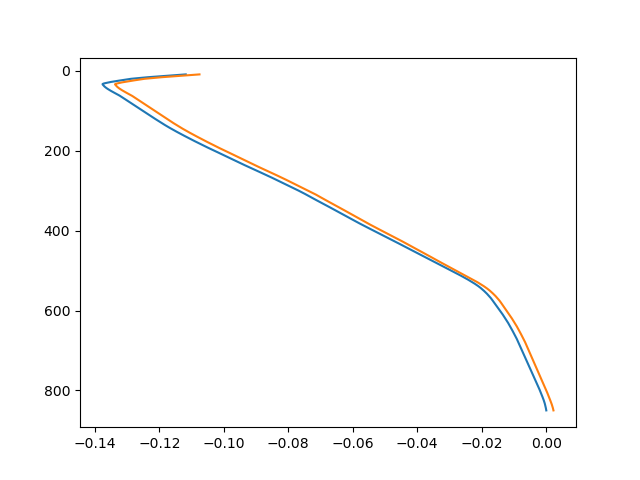

In [273]:
fig = plt.figure()
plt.plot(v_tw,shear.dropna(dim='depth').depth)
plt.plot(v_geo,v_geo.pressure)
plt.gca().invert_yaxis()

In [274]:
cast1

<xarray.Dataset> Size: 74kB
Dimensions:                   (pressure: 1151)
Coordinates:
  * pressure                  (pressure) float64 9kB 9.0 10.0 ... 1.159e+03
    station                   int64 8B 26
    lat                       float64 8B -75.14
    lon                       float64 8B 164.8
Data variables:
    Temperature               (pressure) float64 9kB 1.012 1.071 ... -1.884
    Conservative_Temperature  (pressure) float64 9kB 1.015 1.074 ... -1.915
    Salinity                  (pressure) float64 9kB 34.27 34.27 ... 34.85 34.85
    Absolute_Salinity         (pressure) float64 9kB 34.44 34.43 ... 35.02 35.02
    Potential_Density         (pressure) float64 9kB 27.46 27.46 ... 28.07 28.07
    depth                     (pressure) float64 9kB 8.907 9.888 ... 1.144e+03
    dyn                       (pressure) float64 9kB 0.5402 0.5341 ... 0.07362
Attributes:
    date:     2018-01-11

In [275]:
cast2

<xarray.Dataset> Size: 56kB
Dimensions:                   (pressure: 882)
Coordinates:
  * pressure                  (pressure) float64 7kB 1.0 2.0 3.0 ... 881.0 882.0
    station                   int64 8B 73
    lat                       float64 8B -75.04
    lon                       float64 8B 164.5
Data variables:
    Temperature               (pressure) float64 7kB -1.798 -1.797 ... -1.897
    Conservative_Temperature  (pressure) float64 7kB -1.795 -1.794 ... -1.917
    Salinity                  (pressure) float64 7kB 34.57 34.57 ... 34.84 34.84
    Absolute_Salinity         (pressure) float64 7kB 34.74 34.74 ... 35.01 35.01
    Potential_Density         (pressure) float64 7kB 27.84 27.84 ... 28.06 28.06
    depth                     (pressure) float64 7kB 0.984 1.982 ... 870.0 871.0
    dyn                       (pressure) float64 7kB 0.7868 0.7842 ... 0.002695
Attributes:
    date:     2018-02-15

In [185]:
# now try to estimate via thermal wind balance 
cast1_interp

<xarray.Dataset> Size: 54kB
Dimensions:                   (pressure: 851)
Coordinates:
  * pressure                  (pressure) int64 7kB 0 1 2 3 4 ... 847 848 849 850
    station                   int64 8B 26
    lat                       float64 8B -75.14
    lon                       float64 8B 164.8
Data variables:
    Temperature               (pressure) float64 7kB nan nan nan ... -1.9 -1.899
    Conservative_Temperature  (pressure) float64 7kB nan nan ... -1.919 -1.919
    Salinity                  (pressure) float64 7kB nan nan nan ... 34.85 34.85
    Absolute_Salinity         (pressure) float64 7kB nan nan nan ... 35.02 35.02
    Potential_Density         (pressure) float64 7kB nan nan nan ... 28.07 28.07
    depth                     (pressure) float64 7kB nan nan nan ... 838.5 839.4
    dyn                       (pressure) float64 7kB nan nan ... 0.0046 0.004712
Attributes:
    date:     2018-01-11

### Dynamic Method 

In [56]:
ds_cast = ds_sub.isel(station=0).sortby('Pressure')

# drop NaNs in key variables
mask = (
    np.isfinite(ds_cast.Pressure) &
    np.isfinite(ds_cast.Salinity) &
    np.isfinite(ds_cast.Temperature)
)
ds_cast = ds_cast.isel(sample=mask)

# remove duplicate pressures (VERY important)
_, ind = np.unique(ds_cast.Pressure.values, return_index=True)
ds_cast = ds_cast.isel(sample=np.sort(ind))

In [57]:
ds_cast

<xarray.Dataset> Size: 245kB
Dimensions:                   (sample: 1092)
Coordinates:
  * sample                    (sample) int64 9kB 0 1 2 3 ... 1088 1089 1090 1091
    station                   int64 8B 22
    lat                       float64 8B -75.0
    lon                       float64 8B 165.4
Data variables: (12/27)
    Date                      (sample) object 9kB '2018-01-09' ... '2018-01-09'
    Julian_Day                (sample) float64 9kB 9.197 9.197 ... 9.213 9.213
    ISO_DateTime_UTC          (sample) object 9kB '2018-01-09T04:43:04Z' ... ...
    Pressure                  (sample) float64 9kB 1.0 2.0 ... 1.092e+03
    Depth                     (sample) float64 9kB 0.982 1.978 ... 1.078e+03
    Temperature               (sample) float64 9kB 0.7381 0.734 ... -1.889
    ...                        ...
    Scans_bin                 (sample) float64 9kB 25.0 53.0 48.0 ... 64.0 26.0
    Flag                      (sample) float64 9kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Absolute_Salinity         (sample) float64 9kB 34.73 34.73 ... 35.02 35.02
    Potential_Temperature     (sample) float64 9kB 0.7381 0.7339 ... -1.921
    Conservative_Temperature  (sample) float64 9kB 0.7394 0.7353 ... -1.918
    Potential_Density         (sample) float64 9kB 27.71 27.71 ... 28.07 28.07

In [58]:
ds_cast.Pressure

<xarray.DataArray 'Pressure' (sample: 1092)> Size: 9kB
array([1.000e+00, 2.000e+00, 3.000e+00, ..., 1.090e+03, 1.091e+03,
       1.092e+03], shape=(1092,))
Coordinates:
  * sample   (sample) int64 9kB 0 1 2 3 4 5 6 ... 1086 1087 1088 1089 1090 1091
    station  int64 8B 22
    lat      float64 8B -75.0
    lon      float64 8B 165.4

In [ ]:
# calculate dynamic height 
dyn = gsw.geo_strf_dyn_height(ds_cast.Absolute_Salinity, ds_cast.Conservative_Temperature, ds_cast.Pressure, p_ref=1000)

Text(0, 0.5, 'Pressure (dbar)')

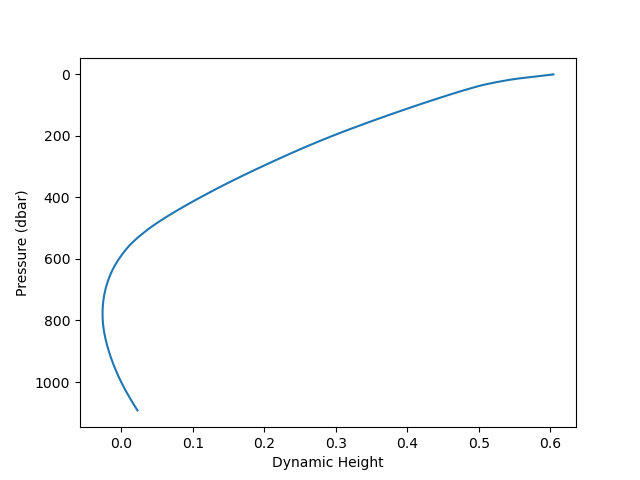

In [61]:
plt.figure()
plt.plot(dyn, ds_cast.Pressure)
plt.gca().invert_yaxis()
plt.xlabel('Dynamic Height')
plt.ylabel('Pressure (dbar)')

In [65]:
ds_sub.isel(station=0).Pressure.max().values

array(1092.)

In [66]:
ds_sub.Pressure.max(dim='sample').min(dim='station').item()

181.0

In [ ]:
# calculate dynamic height for each CTD cast 
for i in range(len(ds_sub)):
    ds_sub[i]['dyn_height'] = gsw.geo_strf_dyn_height(ds_sub[i].Absolute_Salinity, ds_sub[i].Conservative_Temperature,
                                                      ds_sub[i].Pressure, p_ref=ds_sub.isel(station=i).Pressure.max().values)

In [ ]:
ds_sub.where(ds_sub.Pressure)

In [92]:
# 1. get max pressure per station
pmax = ds_sub.Pressure.max(dim='sample')

# 2. create mask for deep casts
deep_mask = pmax > 800

# 3. subset dataset
ds_deep = ds_sub.sel(station=ds_sub.station[deep_mask])

In [93]:
ds_deep

<xarray.Dataset> Size: 7MB
Dimensions:                   (station: 20, sample: 1522)
Coordinates:
  * station                   (station) int64 160B 22 23 24 25 ... 59 60 73 76
  * sample                    (sample) int64 12kB 0 1 2 3 ... 1519 1520 1521
    lat                       (station) float64 160B -75.0 -75.0 ... -74.86
    lon                       (station) float64 160B 165.4 165.8 ... 164.5 165.8
Data variables: (12/28)
    Date                      (station, sample) object 244kB '2018-01-09' ......
    Julian_Day                (station, sample) float64 244kB 9.197 ... nan
    ISO_DateTime_UTC          (station, sample) object 244kB '2018-01-09T04:4...
    Pressure                  (station, sample) float64 244kB 1.0 2.0 ... nan
    Depth                     (station, sample) float64 244kB 0.982 ... nan
    Temperature               (station, sample) float64 244kB 0.7381 ... nan
    ...                        ...
    Flag                      (station, sample) float64 244kB 0.0 0.0 ... nan
    Absolute_Salinity         (station, sample) float64 244kB 34.73 ... nan
    Potential_Temperature     (station, sample) float64 244kB 0.7381 ... nan
    Conservative_Temperature  (station, sample) float64 244kB 0.7394 ... nan
    Potential_Density         (station, sample) float64 244kB 27.71 ... nan
    dyn_height                (station, sample) float64 244kB 0.6042 ... nan

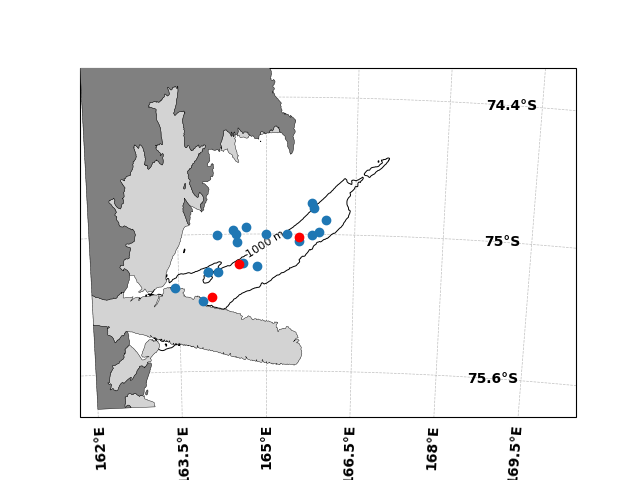

In [94]:
fig, ax = TNB_study_site()

ax.scatter(
    ds_deep.lon,
    ds_deep.lat,
    transform=ccrs.PlateCarree(),
    zorder=10
)

ax.scatter(ditd_lon,ditd_lat,transform=ccrs.PlateCarree(),
    zorder=10,color='r')
ax.scatter(tnbd_lon,tnbd_lat,transform=ccrs.PlateCarree(),
    zorder=10,color='r')
ax.scatter(D_lon,D_lat,transform=ccrs.PlateCarree(),
    zorder=10,color='r')

In [95]:
# 1. choose ONE common reference pressure
p_ref = 800

dyn_all = []

# 2. loop through stations
for st in ds_deep.station.values:

    

    cast = ds_deep.sel(station=st).sortby('Pressure')

    # if cast.Pressure.max() < p_ref:
    #     print(f"Skipping station {st} (too shallow)")
    #     continue

    # basic cleaning (minimal but important)
    mask = (
        np.isfinite(cast.Pressure) &
        np.isfinite(cast.Absolute_Salinity) &
        np.isfinite(cast.Conservative_Temperature)
    )
    cast = cast.isel(sample=mask)

    # remove duplicate pressures
    _, ind = np.unique(cast.Pressure.values, return_index=True)
    cast = cast.isel(sample=np.sort(ind))

    # 3. compute dynamic height
    dyn = gsw.geo_strf_dyn_height(
        cast.Absolute_Salinity.values,
        cast.Conservative_Temperature.values,
        cast.Pressure.values,
        p_ref=p_ref
    )

    # 4. store result
    dyn_da = xr.DataArray(
        dyn,
        coords={'sample': cast.sample.values},
        dims=['sample']
    ).expand_dims(station=[st])

    dyn_all.append(dyn_da)

# 5. combine
ds_deep['dyn_height'] = xr.concat(dyn_all, dim='station')

C:\Users\mblan\AppData\Local\Temp\ipykernel_4088\3492220608.py:47: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'sample' ('sample',) The recommendation is to set join explicitly for this case.
  ds_deep['dyn_height'] = xr.concat(dyn_all, dim='station')


In [96]:
ds_deep

<xarray.Dataset> Size: 7MB
Dimensions:                   (station: 20, sample: 1522)
Coordinates:
  * station                   (station) int64 160B 22 23 24 25 ... 59 60 73 76
  * sample                    (sample) int64 12kB 0 1 2 3 ... 1519 1520 1521
    lat                       (station) float64 160B -75.0 -75.0 ... -74.86
    lon                       (station) float64 160B 165.4 165.8 ... 164.5 165.8
Data variables: (12/28)
    Date                      (station, sample) object 244kB '2018-01-09' ......
    Julian_Day                (station, sample) float64 244kB 9.197 ... nan
    ISO_DateTime_UTC          (station, sample) object 244kB '2018-01-09T04:4...
    Pressure                  (station, sample) float64 244kB 1.0 2.0 ... nan
    Depth                     (station, sample) float64 244kB 0.982 ... nan
    Temperature               (station, sample) float64 244kB 0.7381 ... nan
    ...                        ...
    Flag                      (station, sample) float64 244kB 0.0 0.0 ... nan
    Absolute_Salinity         (station, sample) float64 244kB 34.73 ... nan
    Potential_Temperature     (station, sample) float64 244kB 0.7381 ... nan
    Conservative_Temperature  (station, sample) float64 244kB 0.7394 ... nan
    Potential_Density         (station, sample) float64 244kB 27.71 ... nan
    dyn_height                (station, sample) float64 244kB 0.63 ... nan

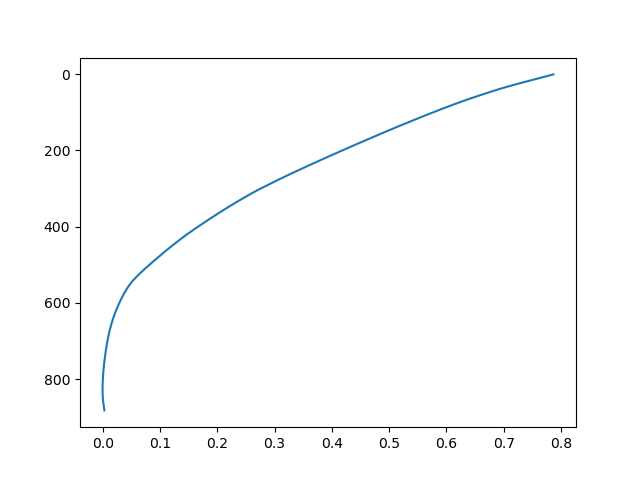

In [98]:
fig = plt.figure()
st=73
plt.plot(ds_deep.sel(station=st).dyn_height,ds_deep.sel(station=st).Pressure)
plt.gca().invert_yaxis()

In [99]:
st1 = ds_deep.sel(station=26)
st2 = ds_deep.sel(station=73)

pmax_common = min(
    float(st1.Pressure.max()),
    float(st2.Pressure.max())
)

p_common = np.arange(0, np.floor(pmax_common) + 1, 1)

In [105]:
np.unique(st1.Pressure)

array([   9.,   10.,   11., ..., 1158., 1159.,   nan], shape=(1152,))

In [106]:
st1.Pressure

<xarray.DataArray 'Pressure' (sample: 1522)> Size: 12kB
array([ 9., 10., 11., ..., nan, nan, nan], shape=(1522,))
Coordinates:
  * sample   (sample) int64 12kB 0 1 2 3 4 5 6 ... 1516 1517 1518 1519 1520 1521
    station  int64 8B 26
    lat      float64 8B -75.14
    lon      float64 8B 164.8

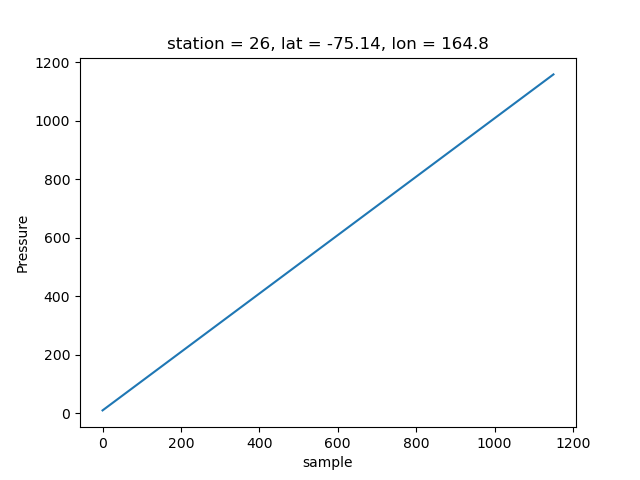

In [102]:
fig = plt.figure()
st1.Pressure.plot()

In [100]:
dyn1 = (
    st1.sortby('Pressure')
       .assign_coords(Pressure=('sample', st1.sortby('Pressure').Pressure.values))
       .swap_dims({'sample': 'Pressure'})['dyn_height']
       .interp(Pressure=p_common)
)

dyn2 = (
    st2.sortby('Pressure')
       .assign_coords(Pressure=('sample', st2.sortby('Pressure').Pressure.values))
       .swap_dims({'sample': 'Pressure'})['dyn_height']
       .interp(Pressure=p_common)
)

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [108]:
ds_deep.swap_dims({'sample':'Pressure'})

ValueError: replacement dimension 'Pressure' is not a 1D variable along the old dimension 'sample'

In [86]:
plt.close('all')

### CTD Casts - Map 1 Region (Towards Amundsen Sea)


In [44]:
ds1 = ds2.where(
    (ds2.lon > -150) & (ds2.lon < -80) &
    (ds2.lat > -80) & (ds2.lat < -63),
    drop=True
)

In [45]:
ds1

<xarray.Dataset> Size: 4MB
Dimensions:                  (station: 13, sample: 1522)
Coordinates:
  * station                  (station) int64 104B 1 3 4 5 6 7 8 9 10 11 12 13 14
  * sample                   (sample) int64 12kB 0 1 2 3 ... 1518 1519 1520 1521
    lat                      (station) float64 104B -64.72 -70.17 ... -74.97
    lon                      (station) float64 104B -87.28 -113.6 ... -145.1
Data variables: (12/23)
    Date                     (station, sample) object 158kB '2017-12-26' ... nan
    Julian_Day               (station, sample) float64 158kB 360.8 360.8 ... nan
    ISO_DateTime_UTC         (station, sample) object 158kB '2017-12-26T19:16...
    Pressure                 (station, sample) float64 158kB 1.0 2.0 ... nan nan
    Depth                    (station, sample) float64 158kB 0.987 1.979 ... nan
    Temperature              (station, sample) float64 158kB 1.25 1.248 ... nan
    ...                       ...
    Scan_Count               (station, sample) float64 158kB 1.292e+04 ... nan
    Salinity                 (station, sample) float64 158kB 33.81 33.81 ... nan
    Salinity_2               (station, sample) float64 158kB 33.81 33.81 ... nan
    Oxygen_Saturation        (station, sample) float64 158kB 7.82 7.821 ... nan
    Scans_bin                (station, sample) float64 158kB 22.0 45.0 ... nan
    Flag                     (station, sample) float64 158kB 0.0 0.0 ... nan nan

Text(0.5, 1.0, 'Map 1: CTD Casts Towards Amundsen Sea')

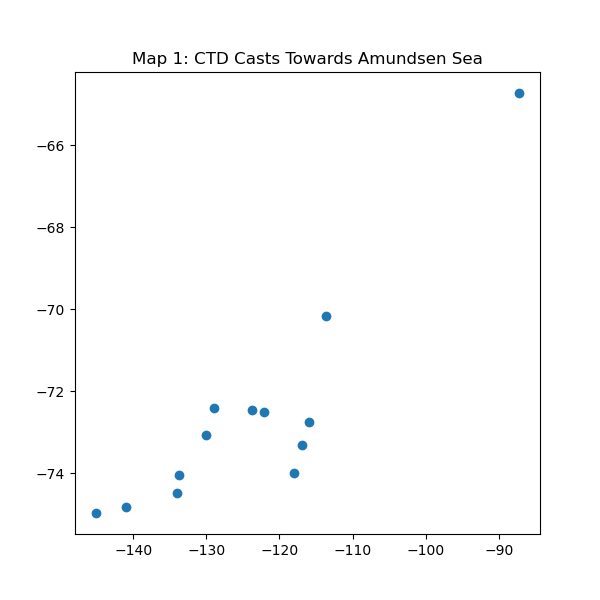

In [46]:
fig = plt.figure(figsize=(6,6))
plt.scatter(ds1.lon,ds1.lat)
plt.title('Map 1: CTD Casts Towards Amundsen Sea')

In [47]:
ds1['Absolute_Salinity'] = gsw.SA_from_SP(ds1.Salinity,ds1.Pressure,ds1.lon,ds1.lat)
# should a reference pressure of zero be used? 
ds1['Potential_Temperature'] = gsw.pt_from_t(ds1.Absolute_Salinity,ds1.Temperature,ds1.Pressure,0)
ds1['Conservative_Temperature'] = gsw.CT_from_pt(ds1.Absolute_Salinity,ds1.Potential_Temperature)
ds1['Potential_Density'] = gsw.sigma0(ds1.Absolute_Salinity,ds1.Conservative_Temperature)

Text(0.5, 0.98, 'Station 13, 2018-01-04')

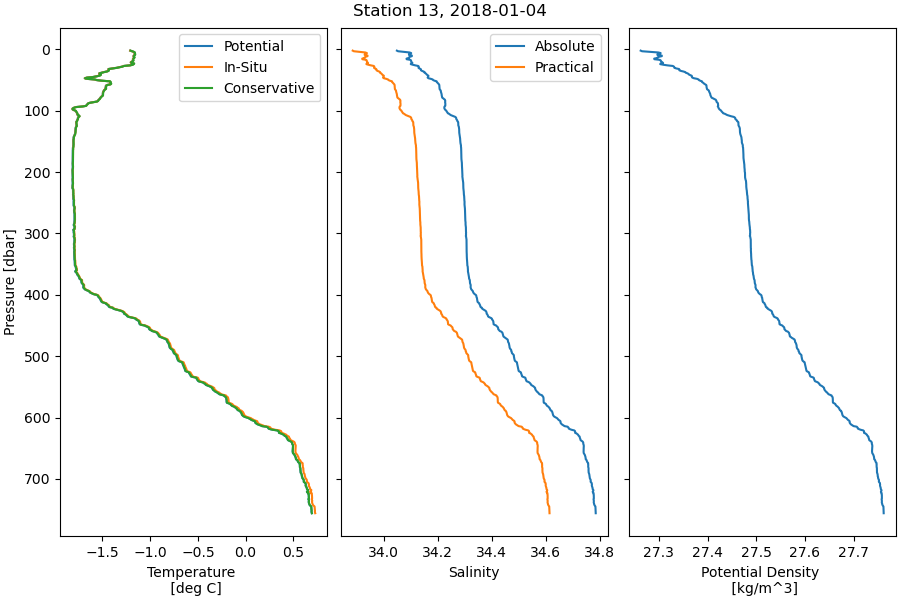

In [48]:
station = 13
ds_st = ds1.sel(station=station)

fig, axes = plt.subplots(1, 3, figsize=(9,6), constrained_layout=True, sharey=True)

# 1st panel
axes[0].plot(ds_st.Potential_Temperature, ds_st.Pressure,label='Potential')
axes[0].plot(ds_st.Temperature, ds_st.Pressure,label='In-Situ')
axes[0].plot(ds_st.Conservative_Temperature, ds_st.Pressure,label='Conservative')
axes[0].legend()
axes[0].set_xlabel('Temperature \n [deg C]')
axes[0].set_ylabel('Pressure [dbar]')
axes[0].invert_yaxis()

# 2nd panel
axes[1].plot(ds_st.Absolute_Salinity, ds_st.Pressure,label='Absolute')
axes[1].plot(ds_st.Salinity, ds_st.Pressure,label='Practical')
axes[1].legend()
axes[1].set_xlabel('Salinity')
axes[1].invert_yaxis()

# 3rd panel
axes[2].plot(ds_st.Potential_Density, ds_st.Pressure)
axes[2].set_xlabel('Potential Density \n [kg/m^3]')
axes[2].invert_yaxis()

# Title
st_num = ds_st.station.item()
date = ds1.Date.sel(station=station).isel(sample=0).item()

fig.suptitle(f'Station {st_num}, {date}')

### Map 2 Region: Ross Sea 

In [49]:
ds_sub2 = ds2.where(
    (ds2.lon > 168) & (ds2.lon < 179) &
    (ds2.lat > -80) & (ds2.lat < -74),
    drop=True
)

In [50]:
ds_sub2

<xarray.Dataset> Size: 5MB
Dimensions:                  (station: 17, sample: 1522)
Coordinates:
  * station                  (station) int64 136B 21 28 29 31 32 ... 68 69 70 71
  * sample                   (sample) int64 12kB 0 1 2 3 ... 1518 1519 1520 1521
    lat                      (station) float64 136B -75.54 -74.75 ... -75.3
    lon                      (station) float64 136B 169.9 173.0 ... 170.5 170.5
Data variables: (12/23)
    Date                     (station, sample) object 207kB '2018-01-08' ... nan
    Julian_Day               (station, sample) float64 207kB 8.666 8.666 ... nan
    ISO_DateTime_UTC         (station, sample) object 207kB '2018-01-08T15:59...
    Pressure                 (station, sample) float64 207kB 9.0 10.0 ... nan
    Depth                    (station, sample) float64 207kB 8.906 9.893 ... nan
    Temperature              (station, sample) float64 207kB 0.7767 ... nan
    ...                       ...
    Scan_Count               (station, sample) float64 207kB 6.976e+03 ... nan
    Salinity                 (station, sample) float64 207kB 34.22 34.18 ... nan
    Salinity_2               (station, sample) float64 207kB 34.22 34.21 ... nan
    Oxygen_Saturation        (station, sample) float64 207kB 7.894 7.922 ... nan
    Scans_bin                (station, sample) float64 207kB 43.0 52.0 ... nan
    Flag                     (station, sample) float64 207kB 0.0 0.0 ... nan nan

Text(0.5, 1.0, 'Map 2: CTD Casts Ross Sea')

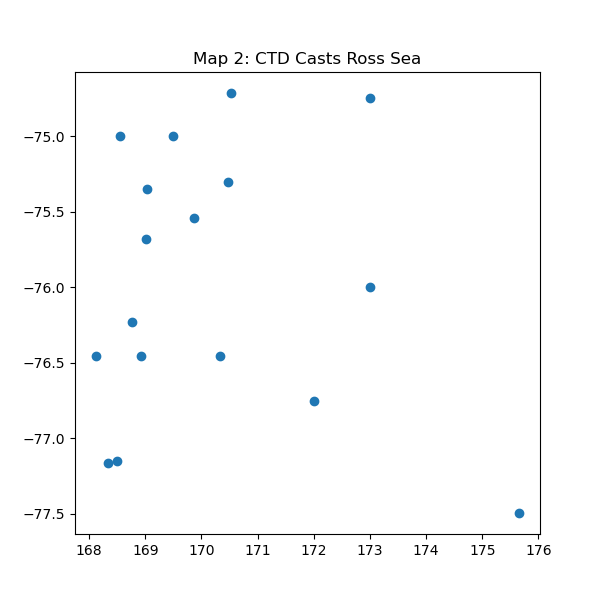

In [51]:
fig = plt.figure(figsize=(6,6))
plt.scatter(ds_sub2.lon,ds_sub2.lat)
plt.title('Map 2: CTD Casts Ross Sea')

In [52]:
ds_sub2['Absolute_Salinity'] = gsw.SA_from_SP(ds_sub2.Salinity,ds_sub2.Pressure,ds_sub2.lon,ds_sub2.lat)
# should a reference pressure of zero be used? 
ds_sub2['Potential_Temperature'] = gsw.pt_from_t(ds_sub2.Absolute_Salinity,ds_sub2.Temperature,ds_sub2.Pressure,0)
ds_sub2['Conservative_Temperature'] = gsw.CT_from_pt(ds_sub2.Absolute_Salinity,ds_sub2.Potential_Temperature)
ds_sub2['Potential_Density'] = gsw.sigma0(ds_sub2.Absolute_Salinity,ds_sub2.Conservative_Temperature)

Text(0.5, 0.98, 'Station 32, 2018-01-17')

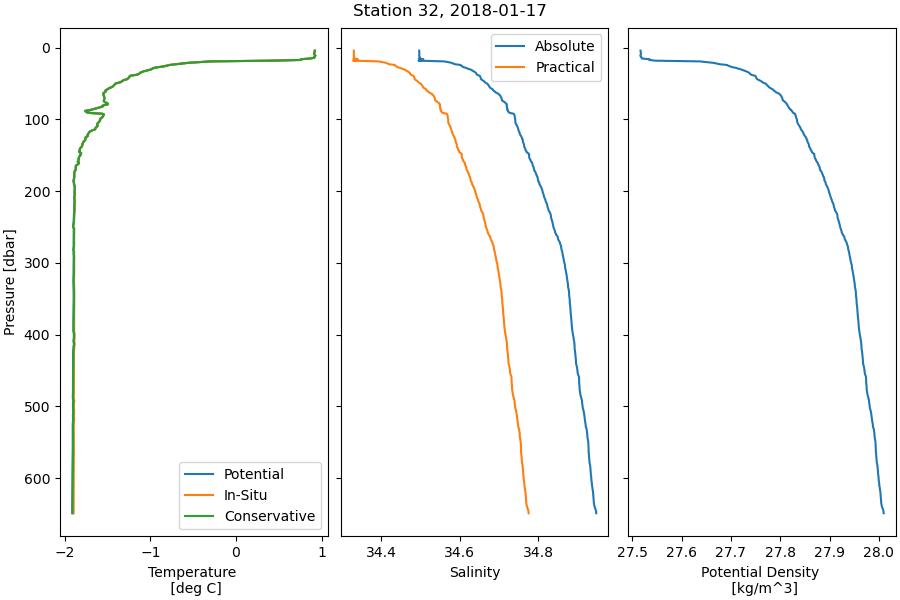

In [53]:
station = 32
ds_st = ds_sub2.sel(station=station)

fig, axes = plt.subplots(1, 3, figsize=(9,6), constrained_layout=True, sharey=True)

# 1st panel
axes[0].plot(ds_st.Potential_Temperature, ds_st.Pressure,label='Potential')
axes[0].plot(ds_st.Temperature, ds_st.Pressure,label='In-Situ')
axes[0].plot(ds_st.Conservative_Temperature, ds_st.Pressure,label='Conservative')
axes[0].legend()
axes[0].set_xlabel('Temperature \n [deg C]')
axes[0].set_ylabel('Pressure [dbar]')
axes[0].invert_yaxis()

# 2nd panel
axes[1].plot(ds_st.Absolute_Salinity, ds_st.Pressure,label='Absolute')
axes[1].plot(ds_st.Salinity, ds_st.Pressure,label='Practical')
axes[1].legend()
axes[1].set_xlabel('Salinity')
axes[1].invert_yaxis()

# 3rd panel
axes[2].plot(ds_st.Potential_Density, ds_st.Pressure)
axes[2].set_xlabel('Potential Density \n [kg/m^3]')
axes[2].invert_yaxis()

# Title
st_num = ds_st.station.item()
date = ds_sub2.Date.sel(station=station).isel(sample=0).item()

fig.suptitle(f'Station {st_num}, {date}')